# TFM — Análisis Exploratorio de Datos (EDA)
**Autora:** Meritxell Abellan Collado  
**Dataset:** Accidentes de tráfico en Madrid (Open Data Ayuntamiento de Madrid)  
**Pregunta de investigación:** ¿Qué características de un accidente de tráfico están asociadas a una mayor probabilidad de que el accidente tenga consecuencias graves?

---

## Objetivo de este notebook

Este notebook realiza un análisis exploratorio completo del dataset de accidentes de tráfico de Madrid.  
El dataset está estructurado a **nivel persona** (cada fila es una persona implicada en un accidente), pero la unidad de análisis del TFM es el **accidente**. Por tanto, el EDA se divide en dos niveles:

1. Exploración del dataset en su forma original (nivel persona)
2. Análisis orientado a la variable objetivo: `LESIVIDAD`, que se transformará a nivel accidente en el siguiente notebook

Al final de cada sección se incluye un resumen de los hallazgos más relevantes.

---
## 0. Carga de librerías y datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Estilo global de gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


In [2]:
# Carga del dataset
DATA_PATH = '../data/raw/accidentes-trafico.xlsx'

df = pd.read_excel(DATA_PATH)

print(f'Dataset cargado: {df.shape[0]:,} filas | {df.shape[1]} columnas')

Dataset cargado: 199,078 filas | 26 columnas


El dataset incluye registros de testigos, que no están directamente implicados en los accidentes y que pueden distorsionar el estudio. Por ello, se suprimen de manera que solo se tienen en consideración los implicados directos en cada accidente.

In [3]:
# Excluir testigos desde el inicio del análisis
df['TIPO PERSONA'] = df['TIPO PERSONA'].str.strip()
n_testigos = (df['TIPO PERSONA'] == 'TESTIGO').sum()
df = df[df['TIPO PERSONA'] != 'TESTIGO']

print(f'Dataset cargado: {len(df) + n_testigos:,} filas originales')
print(f'Testigos excluidos: {n_testigos:,}')
print(f'Registros para el análisis: {len(df):,}')

Dataset cargado: 199,078 filas originales
Testigos excluidos: 24,725
Registros para el análisis: 174,353


---
## 1. Entendimiento del dataset

Antes de cualquier análisis, es fundamental entender qué contiene el dataset: qué representa cada columna, cuántos registros hay, qué tipos de datos se usan y si existen valores nulos o inconsistentes.

El dataset recoge información a nivel persona: para cada accidente (`Nº PARTE`) puede haber varias filas, una por cada persona implicada (conductor, peatón, viajero, testigo). Las variables se pueden agrupar en:
- **Identificación:** `Nº PARTE`, `Nº`, `FECHA`
- **Tiempo:** `RANGO HORARIO`, `DIA SEMANA`
- **Lugar:** `DISTRITO`, `LUGAR ACCIDENTE`
- **Condiciones atmosféricas:** columnas `CPFA_*`
- **Estado del firme:** columnas `CPSV_*`
- **Accidente:** `TIPO ACCIDENTE`, `Nº VICTIMAS *`
- **Persona:** `Tipo Vehiculo`, `TIPO PERSONA`, `SEXO`, `Tramo Edad`
- **Variable objetivo:** `LESIVIDAD`

In [4]:
# Primeras filas
df.head()

,FECHA,RANGO HORARIO,DIA SEMANA,DISTRITO,LUGAR ACCIDENTE,Nº,Nº PARTE,CPFA Granizo,CPFA Hielo,CPFA Lluvia,...,CPSV Grava Suelta,CPSV Hielo,CPSV Seca Y Limpia,Nº VICTIMAS *,TIPO ACCIDENTE,Tipo Vehiculo,TIPO PERSONA,SEXO,LESIVIDAD,Tramo Edad
0,2012-01-01,DE 2:00 A 2:59,DOMINGO,CENTRO,CALLE DE LA PRINCESA NUM ...,10.0,2012/98,NO,NO,NO,...,NO,NO,SI,2,ATROPELLO,NO ASIGNADO,PEATON,HOMBRE,HL,DE 25 A 29 AÑOS
1,2012-01-01,DE 2:00 A 2:59,DOMINGO,CENTRO,CALLE DE LA PRINCESA NUM ...,10.0,2012/98,NO,NO,NO,...,NO,NO,SI,2,ATROPELLO,NO ASIGNADO,PEATON,MUJER,HL,DE 25 A 29 AÑOS
3,2012-01-01,DE 2:00 A 2:59,DOMINGO,CENTRO,CALLE DE LA PRINCESA NUM ...,10.0,2012/98,NO,NO,NO,...,NO,NO,SI,2,ATROPELLO,AUTO-TAXI,CONDUCTOR,HOMBRE,IL,DE 35 A 39 AÑOS
4,2012-01-01,DE 2:00 A 2:59,DOMINGO,PUENTE DE VALLECAS,AVENIDA DE SAN DIEGO NUM ...,96.0,2012/118,NO,NO,NO,...,NO,NO,SI,1,OTRAS CAUSAS,TURISMO,CONDUCTOR,HOMBRE,IL,DE 25 A 29 AÑOS
5,2012-01-01,DE 2:00 A 2:59,DOMINGO,PUENTE DE VALLECAS,AVENIDA DE SAN DIEGO NUM ...,96.0,2012/118,NO,NO,NO,...,NO,NO,SI,1,OTRAS CAUSAS,TURISMO,CONDUCTOR,HOMBRE,IL,DE 35 A 39 AÑOS


In [5]:
# Tipos de datos y valores no nulos
df.info()

<class 'pandas.DataFrame'>
Index: 174353 entries, 0 to 199077
Data columns (total 26 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   FECHA               174353 non-null  datetime64[us]
 1   RANGO HORARIO       174353 non-null  str           
 2   DIA SEMANA          174353 non-null  str           
 3   DISTRITO            174353 non-null  str           
 4   LUGAR ACCIDENTE     174353 non-null  str           
 5   Nº                  171680 non-null  float64       
 6   Nº PARTE            174353 non-null  str           
 7   CPFA Granizo        174353 non-null  str           
 8   CPFA Hielo          174353 non-null  str           
 9   CPFA Lluvia         174353 non-null  str           
 10  CPFA Niebla         174353 non-null  str           
 11  CPFA Seco           174353 non-null  str           
 12  CPFA Nieve          174353 non-null  str           
 13  CPSV Mojada         174353 non-null  str     

In [6]:
# Estadísticas descriptivas básicas
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
FECHA,174353,NaN,NaN,NaN,2015-08-04 20:49:34.682397,2012-01-01 00:00:00,2013-11-17 00:00:00,2015-08-26 00:00:00,2017-05-12 00:00:00,2018-12-31 00:00:00,NaN
RANGO HORARIO,174353,24,DE 14:00 A 14:59,12881,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DIA SEMANA,174353,7,VIERNES,29863,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DISTRITO,174353,22,SALAMANCA,13157,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LUGAR ACCIDENTE,174353,13960,AUTOVIA M-30 CALZADA 1 KM. ...,5965,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Nº,171680.0,NaN,NaN,NaN,1039.167952,0.0,0.0,1.0,52.0,53500.0,4052.979017
Nº PARTE,174353,68773,2012/11769,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CPFA Granizo,174353,2,NO,174327,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CPFA Hielo,174353,2,NO,174264,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CPFA Lluvia,174353,2,NO,154476,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [71]:
# Número de accidentes únicos
n_accidentes = df['Nº PARTE'].nunique()
n_personas = len(df)
print(f'Registros totales (nivel persona): {n_personas:,}')
print(f'Accidentes únicos (nivel accidente): {n_accidentes:,}')
print(f'Media de personas implicadas por accidente: {n_personas / n_accidentes:.2f}')

Registros totales (nivel persona): 174,353
Accidentes únicos (nivel accidente): 68,773
Media de personas implicadas por accidente: 2.54


In [72]:
# Duplicados exactos (todas las columnas)
duplicados = df.duplicated().sum()
print(f'Filas duplicadas exactas: {duplicados}')

# Duplicados por campos clave (misma persona en el mismo accidente)
duplicados_clave = df.duplicated(subset=['Nº PARTE', 'TIPO PERSONA', 'SEXO', 'Tramo Edad', 'LESIVIDAD']).sum()
print(f'Posibles duplicados por campos clave: {duplicados_clave}')


Filas duplicadas exactas: 4065
Posibles duplicados por campos clave: 4766


In [73]:
# Rango temporal del dataset
df['FECHA'] = pd.to_datetime(df['FECHA'])
print(f'Desde: {df["FECHA"].min().date()}')
print(f'Hasta: {df["FECHA"].max().date()}')
print(f'Años cubiertos: {sorted(df["FECHA"].dt.year.unique())}')

Desde: 2012-01-01
Hasta: 2018-12-31
Años cubiertos: [np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018)]


In [74]:
# Valores únicos por columna categórica
cols_categoricas = df.select_dtypes(include='object').columns
for col in cols_categoricas:
    valores = df[col].str.strip().unique()
    print(f'\n{col} ({len(valores)} valores únicos):')
    print(sorted([str(v) for v in valores]))


RANGO HORARIO (24 valores únicos):
['DE 00:00 A 00:59', 'DE 10:00 A 10:59', 'DE 11:00 A 11:59', 'DE 12:00 A 12:59', 'DE 13:00 A 13:59', 'DE 14:00 A 14:59', 'DE 15:00 A 15:59', 'DE 16:00 A 16:59', 'DE 17:00 A 17:59', 'DE 18:00 A 18:59', 'DE 19:00 A 19:59', 'DE 1:00 A 1:59', 'DE 20:00 A 20:59', 'DE 21:00 A 21:59', 'DE 22:00 A 22:59', 'DE 23:00 A 23:59', 'DE 2:00 A 2:59', 'DE 3:00 A 3:59', 'DE 4:00 A 4:59', 'DE 5:00 A 5:59', 'DE 6:00 A 6:59', 'DE 7:00 A 7:59', 'DE 8:00 A 8:59', 'DE 9:00 A 9:59']

DIA SEMANA (7 valores únicos):
['DOMINGO', 'JUEVES', 'LUNES', 'MARTES', 'MIERCOLES', 'SABADO', 'VIERNES']

DISTRITO (21 valores únicos):
['ARGANZUELA', 'BARAJAS', 'CARABANCHEL', 'CENTRO', 'CHAMARTIN', 'CHAMBERI', 'CIUDAD LINEAL', 'FUENCARRAL-EL PARDO', 'HORTALEZA', 'LATINA', 'MONCLOA-ARAVACA', 'MORATALAZ', 'PUENTE DE VALLECAS', 'RETIRO', 'SALAMANCA', 'SAN BLAS', 'TETUAN', 'USERA', 'VICALVARO', 'VILLA DE VALLECAS', 'VILLAVERDE']

LUGAR ACCIDENTE (13958 valores únicos):
['ACCESO  M-40 SALIDA AVDA.

In [75]:
# Análisis de valores nulos
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
nulos_df = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': nulos_pct})
nulos_df = nulos_df[nulos_df['Nulos'] > 0].sort_values('Nulos', ascending=False)

if nulos_df.empty:
    print('No hay valores nulos en el dataset.')
else:
    print(nulos_df)

    Nulos  Porcentaje (%)
Nº   2673            1.53


### 📝 Resumen — Sección 1

> - El dataset contiene 199.078 registros a nivel persona, correspondientes a 68.773 accidentes únicos. No obstante, se han suprimido todas las filas de testigos, puesto que no tienen implicación directa con los accidentes. De esta manera, trabajamos con 174.353 registros de personas, manteniendo el número de accidentes identificados inicialmente.
> - Hay 4.065 filas duplicadas exactas y 4.766 posibles duplicados por campos clave (en los que el perfil de la víctima es el mismo). En la parte de Preprocesado veremos cómo tratar estos duplicados.
> - De media, cada accidente cuenta con 2.54 víctimas (entendiendo por víctimas, personas que han quedado heridas leve, graves, y/o fallecidos).
> - El dataset cubre el período entre el 1 de Enero de 2012 y el 31 de Diciembre de 2018 en los 21 distritos de la Comunidad de Madrid.
> - Solamente se han detectado valores nulos en la columna "Nº", que hace referencia al número de la dirección o número de KM de la vía en que se ha producido el accidente. Estos nulos corresponden a los casos en que el lugar del accidente es un cruce entre dos vías.
> - Respecto a la tipología de las variables estudiadas, hay 26 columnas, de las cuales 25 categóricas y 1 numérica.

---
## 2. Variable objetivo: LESIVIDAD

La variable `LESIVIDAD` recoge el grado de lesión de cada persona implicada en un accidente. Es la base para construir la variable objetivo del modelo.

Los valores son:
- **IL** — Ileso (sin lesiones)
- **HL** — Herido leve
- **HG** — Herido grave
- **MT** — Fallecido
- **NO ASIGNADA** — Sin clasificar (se excluirá en preprocesado)

En esta sección se analiza la distribución de `LESIVIDAD` a nivel persona, y se razona cómo se derivará la variable objetivo a nivel accidente, que será la máxima lesividad entre todos los implicados.

In [77]:
# Limpiar espacios en LESIVIDAD
df['LESIVIDAD'] = df['LESIVIDAD'].str.strip()

# Distribución absoluta y relativa
lesividad_dist = df['LESIVIDAD'].value_counts(dropna=False)
lesividad_pct = df['LESIVIDAD'].value_counts(normalize=True, dropna=False) * 100
lesividad_tabla = pd.DataFrame({'Frecuencia': lesividad_dist, 'Porcentaje (%)': lesividad_pct.round(2)})
print(lesividad_tabla)

             Frecuencia  Porcentaje (%)
LESIVIDAD                              
HL                80869           46.38
IL                78526           45.04
NO ASIGNADA        7860            4.51
HG                 6886            3.95
MT                  212            0.12


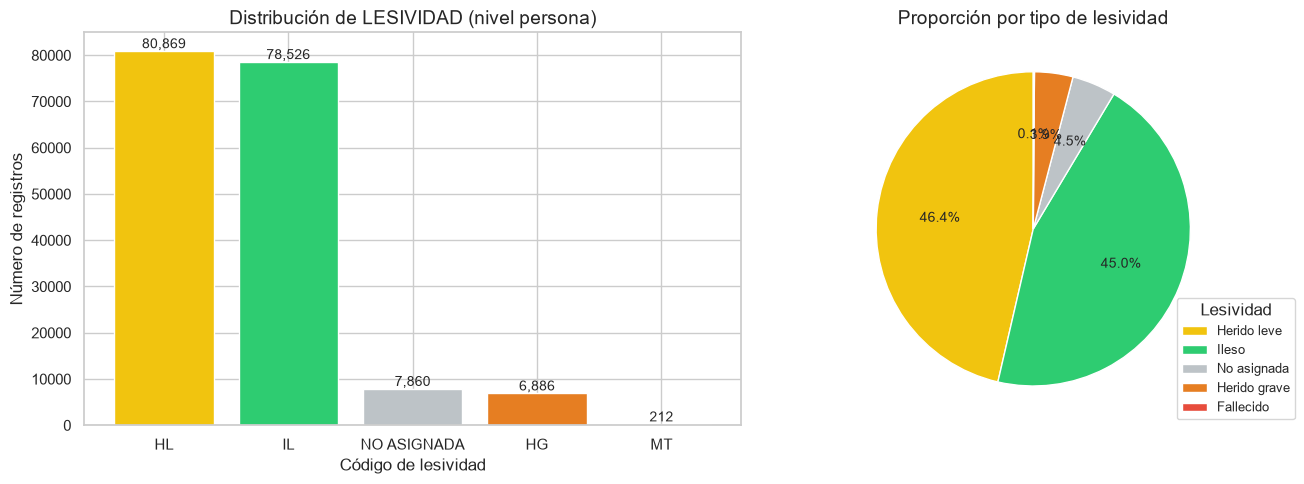

In [84]:
# Gráfico de distribución de LESIVIDAD
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colores_lesividad_ext = {
    'IL': '#2ecc71',
    'HL': '#f1c40f',
    'HG': '#e67e22',
    'MT': '#e74c3c',
    'NO ASIGNADA': '#bdc3c7'
}

order = lesividad_dist.index.tolist()
colores_orden = [colores_lesividad_ext[c.strip()] for c in order]

# Barplot
axes[0].bar(order, lesividad_dist.values, color=colores_orden, edgecolor='white')
axes[0].set_title('Distribución de LESIVIDAD (nivel persona)', fontsize=14)
axes[0].set_xlabel('Código de lesividad')
axes[0].set_ylabel('Número de registros')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

# Pie chart
labels_map = {'IL': 'Ileso', 'HL': 'Herido leve', 'HG': 'Herido grave', 'MT': 'Fallecido', 'NO ASIGNADA': 'No asignada'}
labels_pie = [labels_map[c.strip()] for c in order]
wedges, _, _ = axes[1].pie(lesividad_dist.values, labels=None, autopct='%1.1f%%',
                            colors=colores_orden, startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Proporción por tipo de lesividad', fontsize=14)
axes[1].legend(wedges, labels_pie, title='Lesividad', loc='lower left',
               bbox_to_anchor=(0.85, 0), fontsize=9)

plt.tight_layout()
plt.savefig('../figures/01_distribucion_lesividad.png', dpi=150)
plt.show()

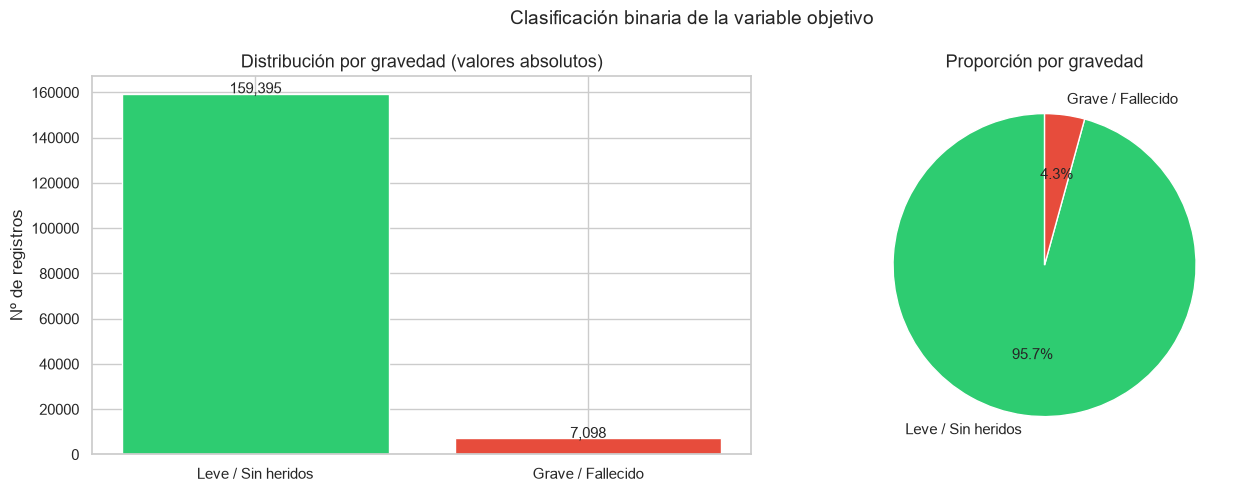


Desequilibrio de clases — ratio: 22.5:1


In [85]:
# Clasificación binaria: Leve/Sin heridos vs Grave/Fallecido
orden_lesividad = ['IL', 'HL', 'HG', 'MT']
colores_lesividad = {'IL': '#2ecc71', 'HL': '#f1c40f', 'HG': '#e67e22', 'MT': '#e74c3c'}

df_sin_na = df[df['LESIVIDAD'].isin(orden_lesividad)].copy()
df_sin_na['GRAVEDAD'] = df_sin_na['LESIVIDAD'].map({
    'IL': 'Leve / Sin heridos', 'HL': 'Leve / Sin heridos',
    'HG': 'Grave / Fallecido',  'MT': 'Grave / Fallecido'
})
df_sin_na['GRAVE'] = df_sin_na['LESIVIDAD'].isin(['HG', 'MT']).astype(int)

gravedad_counts = df_sin_na['GRAVEDAD'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_grav = ['#2ecc71', '#e74c3c']
axes[0].bar(gravedad_counts.index, gravedad_counts.values, color=colors_grav, edgecolor='white')
axes[0].set_title('Distribución por gravedad (valores absolutos)', fontsize=13)
axes[0].set_ylabel('Nº de registros')
for bar, val in zip(axes[0].patches, gravedad_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', fontsize=11)

axes[1].pie(gravedad_counts.values, labels=gravedad_counts.index,
            autopct='%1.1f%%', colors=colors_grav, startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Proporción por gravedad', fontsize=13)

plt.suptitle('Clasificación binaria de la variable objetivo', fontsize=14)
plt.tight_layout()
plt.savefig('../figures/01b_gravedad_binaria.png', dpi=150)
plt.show()

print(f'\nDesequilibrio de clases — ratio: {gravedad_counts.max()/gravedad_counts.min():.1f}:1')

In [86]:
# Definición del orden de gravedad para construir la variable objetivo
orden_gravedad = {'IL': 0, 'HL': 1, 'HG': 2, 'MT': 3}

print('Orden de gravedad definido:')
for k, v in orden_gravedad.items():
    print(f'  {k} → nivel {v}')

print('\nNota: la variable objetivo a nivel accidente será la LESIVIDAD máxima entre todos los implicados.')

Orden de gravedad definido:
  IL → nivel 0
  HL → nivel 1
  HG → nivel 2
  MT → nivel 3

Nota: la variable objetivo a nivel accidente será la LESIVIDAD máxima entre todos los implicados.


### 📝 Resumen — Sección 2

> - La categoría más frecuente es HL (herido leve) con un total de 80.869 registros (46,4%), aunque le sigue de cerca IL (ileso) con 78.526 registros (45%).
> - Se eliminan los 7.860 registros con LESIVIDAD 'NO ASIGNADA' (4,51%) para el estudio de la variable objetivo.
> - Las personas que resultan heridas graves y fallecidas representan el 4,3% del total de víctimas. Esto supone un notable **desequilibrio de clases** que se abordará en la fase de modelización.
> - Decisión sobre la variable objetivo: se usará **clasificación binaria** (accidente grave/accidente leve) puesto que el estudio se centra en predecir si un accidente de tráfico será grave o no dadas las condiciones externas en que sucede.

---
## 3. Análisis temporal

El tiempo es una variable fundamental en la accidentalidad vial. En esta sección se analiza la distribución de accidentes por año, mes, día de la semana y franja horaria. Se añade un heatmap que combina hora y día para identificar los momentos de mayor riesgo, y una serie temporal para detectar tendencias.

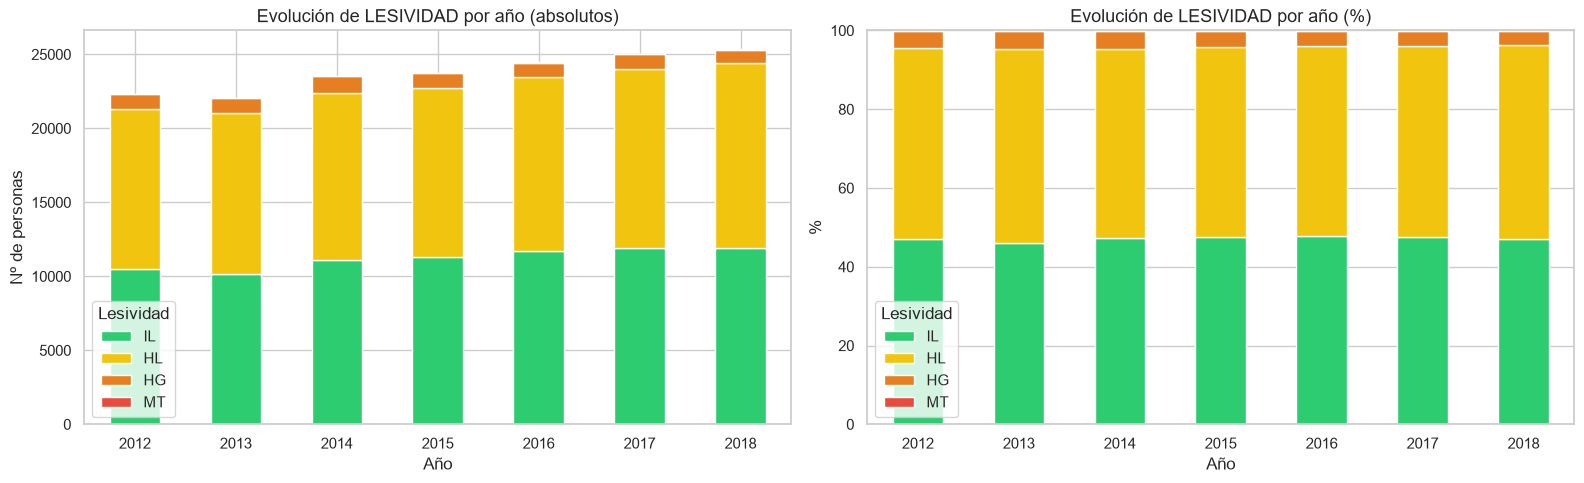

In [87]:
# Evolución de la gravedad por año
df['AÑO'] = df['FECHA'].dt.year
df['MES'] = df['FECHA'].dt.month

df_año = df[df['LESIVIDAD'].isin(orden_lesividad)].copy()
lesividad_año = (df_año.groupby(['AÑO', 'LESIVIDAD'])
                        .size()
                        .unstack(fill_value=0)
                        .reindex(columns=orden_lesividad, fill_value=0))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

lesividad_año.plot(kind='bar', stacked=True, ax=axes[0],
                   color=[colores_lesividad[c] for c in orden_lesividad], edgecolor='white')
axes[0].set_title('Evolución de LESIVIDAD por año (absolutos)', fontsize=13)
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Nº de personas')
axes[0].legend(title='Lesividad')
axes[0].tick_params(axis='x', rotation=0)

lesividad_año_pct = lesividad_año.div(lesividad_año.sum(axis=1), axis=0) * 100
lesividad_año_pct.plot(kind='bar', stacked=True, ax=axes[1],
                       color=[colores_lesividad[c] for c in orden_lesividad], edgecolor='white')
axes[1].set_title('Evolución de LESIVIDAD por año (%)', fontsize=13)
axes[1].set_xlabel('Año')
axes[1].set_ylabel('%')
axes[1].set_ylim(0, 100)
axes[1].legend(title='Lesividad')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../figures/01c_lesividad_por_año.png', dpi=150)
plt.show()

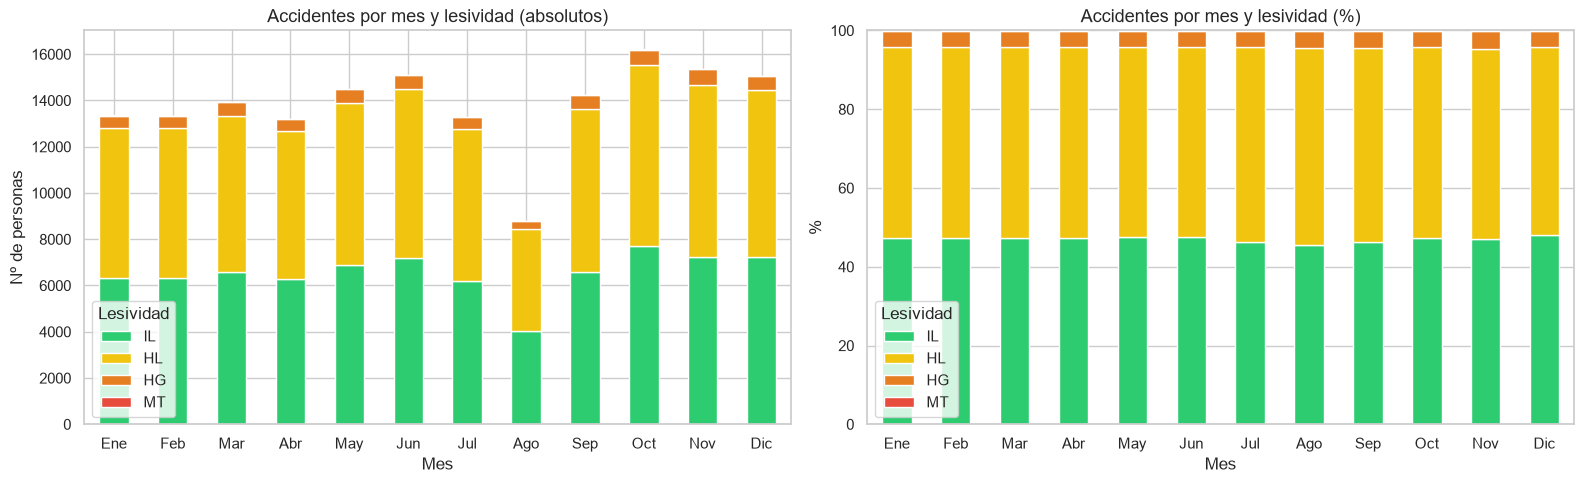

In [89]:
# Accidentes por mes con lesividad apilada
meses = {1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun',
          7:'Jul',8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic'}

df_mes = df[df['LESIVIDAD'].isin(orden_lesividad)].copy()
lesividad_mes = (df_mes.groupby(['MES', 'LESIVIDAD'])
                       .size()
                       .unstack(fill_value=0)
                       .reindex(columns=orden_lesividad, fill_value=0))
lesividad_mes.index = lesividad_mes.index.map(meses)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

lesividad_mes.plot(kind='bar', stacked=True, ax=axes[0],
                   color=[colores_lesividad[c] for c in orden_lesividad], edgecolor='white')
axes[0].set_title('Accidentes por mes y lesividad (absolutos)', fontsize=13)
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Nº de personas')
axes[0].legend(title='Lesividad')
axes[0].tick_params(axis='x', rotation=0)

lesividad_mes_pct = lesividad_mes.div(lesividad_mes.sum(axis=1), axis=0) * 100
lesividad_mes_pct.plot(kind='bar', stacked=True, ax=axes[1],
                       color=[colores_lesividad[c] for c in orden_lesividad], edgecolor='white')
axes[1].set_title('Accidentes por mes y lesividad (%)', fontsize=13)
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('%')
axes[1].set_ylim(0, 100)
axes[1].legend(title='Lesividad')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../figures/03_accidentes_por_mes.png', dpi=150)
plt.show()

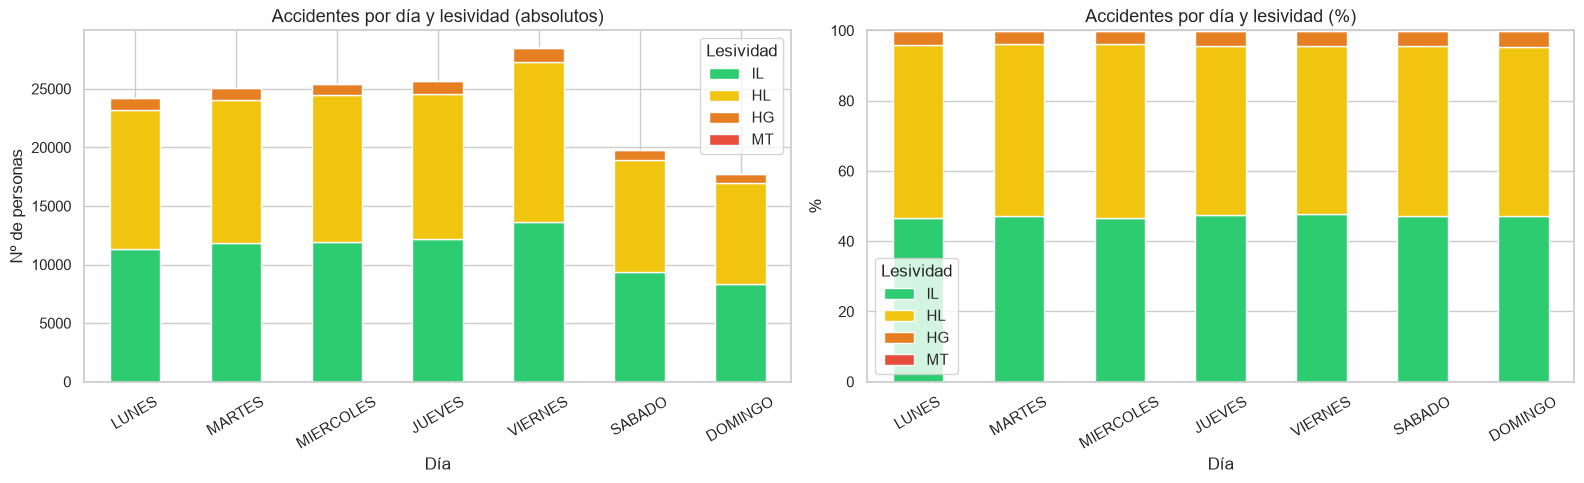

In [91]:
# Accidentes por día de la semana con lesividad apilada
df['DIA SEMANA'] = df['DIA SEMANA'].str.strip()
orden_dias = ['LUNES', 'MARTES', 'MIERCOLES', 'JUEVES', 'VIERNES', 'SABADO', 'DOMINGO']

df_dia = df[df['LESIVIDAD'].isin(orden_lesividad)].copy()
lesividad_dia = (df_dia.groupby(['DIA SEMANA', 'LESIVIDAD'])
                       .size()
                       .unstack(fill_value=0)
                       .reindex(index=orden_dias, columns=orden_lesividad, fill_value=0))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

lesividad_dia.plot(kind='bar', stacked=True, ax=axes[0],
                   color=[colores_lesividad[c] for c in orden_lesividad], edgecolor='white')
axes[0].set_title('Accidentes por día y lesividad (absolutos)', fontsize=13)
axes[0].set_xlabel('Día')
axes[0].set_ylabel('Nº de personas')
axes[0].legend(title='Lesividad')
axes[0].tick_params(axis='x', rotation=30)

lesividad_dia_pct = lesividad_dia.div(lesividad_dia.sum(axis=1), axis=0) * 100
lesividad_dia_pct.plot(kind='bar', stacked=True, ax=axes[1],
                       color=[colores_lesividad[c] for c in orden_lesividad], edgecolor='white')
axes[1].set_title('Accidentes por día y lesividad (%)', fontsize=13)
axes[1].set_xlabel('Día')
axes[1].set_ylabel('%')
axes[1].set_ylim(0, 100)
axes[1].legend(title='Lesividad')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../figures/04_accidentes_por_dia.png', dpi=150)
plt.show()

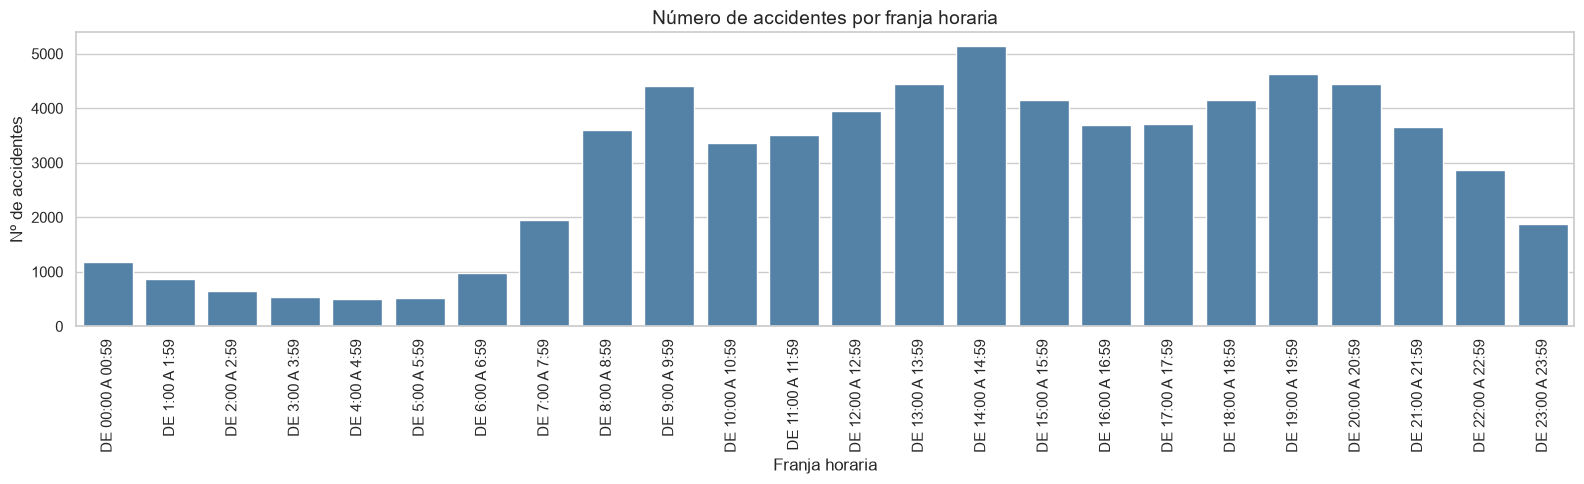

   RANGO HORARIO  Accidentes  Porcentaje (%)
DE 00:00 A 00:59        1176            1.71
  DE 1:00 A 1:59         872            1.27
  DE 2:00 A 2:59         654            0.95
  DE 3:00 A 3:59         537            0.78
  DE 4:00 A 4:59         501            0.73
  DE 5:00 A 5:59         520            0.76
  DE 6:00 A 6:59         985            1.43
  DE 7:00 A 7:59        1956            2.84
  DE 8:00 A 8:59        3600            5.23
  DE 9:00 A 9:59        4405            6.41
DE 10:00 A 10:59        3366            4.89
DE 11:00 A 11:59        3502            5.09
DE 12:00 A 12:59        3943            5.73
DE 13:00 A 13:59        4438            6.45
DE 14:00 A 14:59        5133            7.46
DE 15:00 A 15:59        4144            6.03
DE 16:00 A 16:59        3693            5.37
DE 17:00 A 17:59        3714            5.40
DE 18:00 A 18:59        4151            6.04
DE 19:00 A 19:59        4631            6.73
DE 20:00 A 20:59        4451            6.47
DE 21:00 A

In [92]:
# Franja horaria — orden cronológico
df['RANGO HORARIO'] = df['RANGO HORARIO'].str.strip()

accidentes_hora = (df.drop_duplicates('Nº PARTE')
                     .groupby('RANGO HORARIO').size()
                     .reset_index(name='Accidentes'))

# Sort by the numeric hour extracted from the string, regardless of format
accidentes_hora['HORA'] = accidentes_hora['RANGO HORARIO'].str.extract(r'(\d+)').astype(int)
accidentes_hora = accidentes_hora.sort_values('HORA').reset_index(drop=True)
accidentes_hora['Porcentaje (%)'] = (accidentes_hora['Accidentes'] / accidentes_hora['Accidentes'].sum() * 100).round(2)

fig, ax = plt.subplots(figsize=(16, 5))
sns.barplot(data=accidentes_hora, x='RANGO HORARIO', y='Accidentes', ax=ax, color='steelblue')
ax.set_title('Número de accidentes por franja horaria', fontsize=14)
ax.set_xlabel('Franja horaria')
ax.set_ylabel('Nº de accidentes')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('../figures/05_accidentes_por_hora.png', dpi=150)
plt.show()

print(accidentes_hora[['RANGO HORARIO', 'Accidentes', 'Porcentaje (%)']].to_string(index=False))

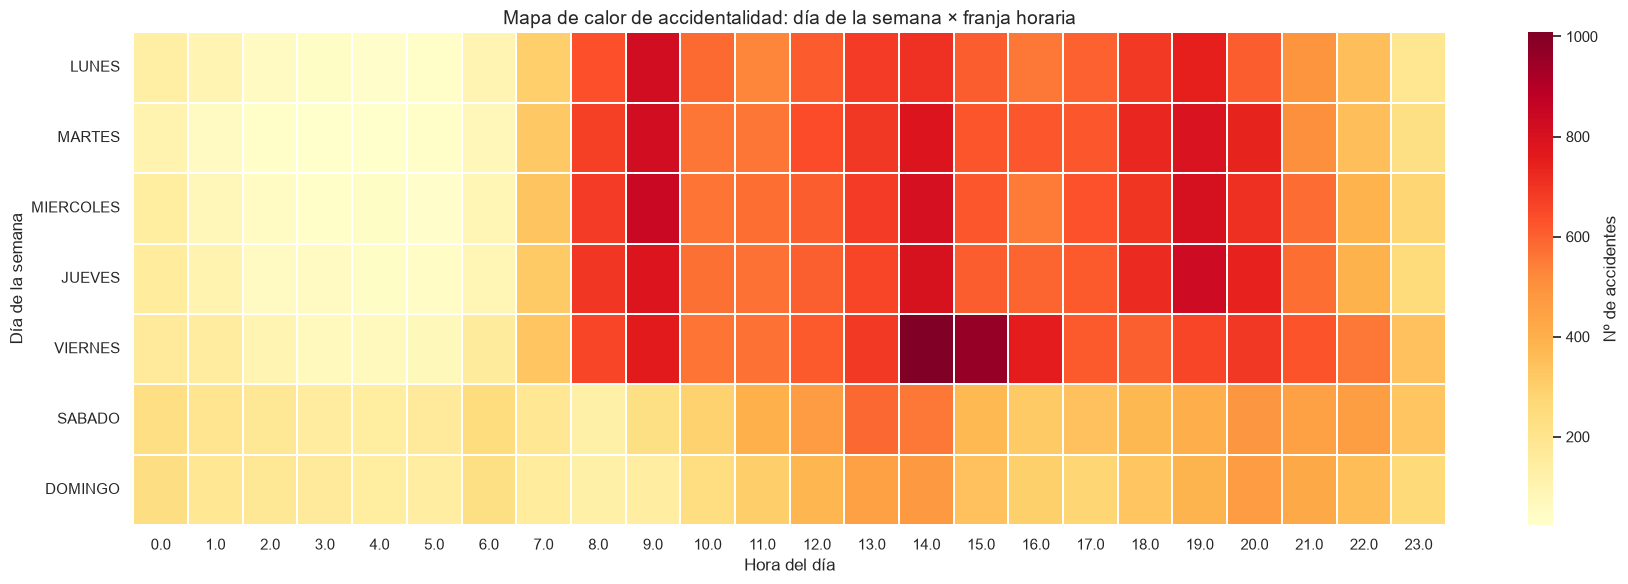

In [95]:
# Heatmap: hora × día de la semana
# Extrae la hora numérica para el eje
df['HORA'] = df['RANGO HORARIO'].str.extract(r'(\d+)').astype(float)

heatmap_data = (df.drop_duplicates('Nº PARTE')
                  .groupby(['DIA SEMANA', 'HORA'])
                  .size()
                  .unstack(fill_value=0)
                  .reindex(orden_dias, fill_value=0))

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(heatmap_data, cmap='YlOrRd', ax=ax, linewidths=0.3,
            cbar_kws={'label': 'Nº de accidentes'})
ax.set_title('Mapa de calor de accidentalidad: día de la semana × franja horaria', fontsize=14)
ax.set_xlabel('Hora del día')
ax.set_ylabel('Día de la semana')
plt.tight_layout()
plt.savefig('../figures/05b_heatmap_dia_hora.png', dpi=150)
plt.show()

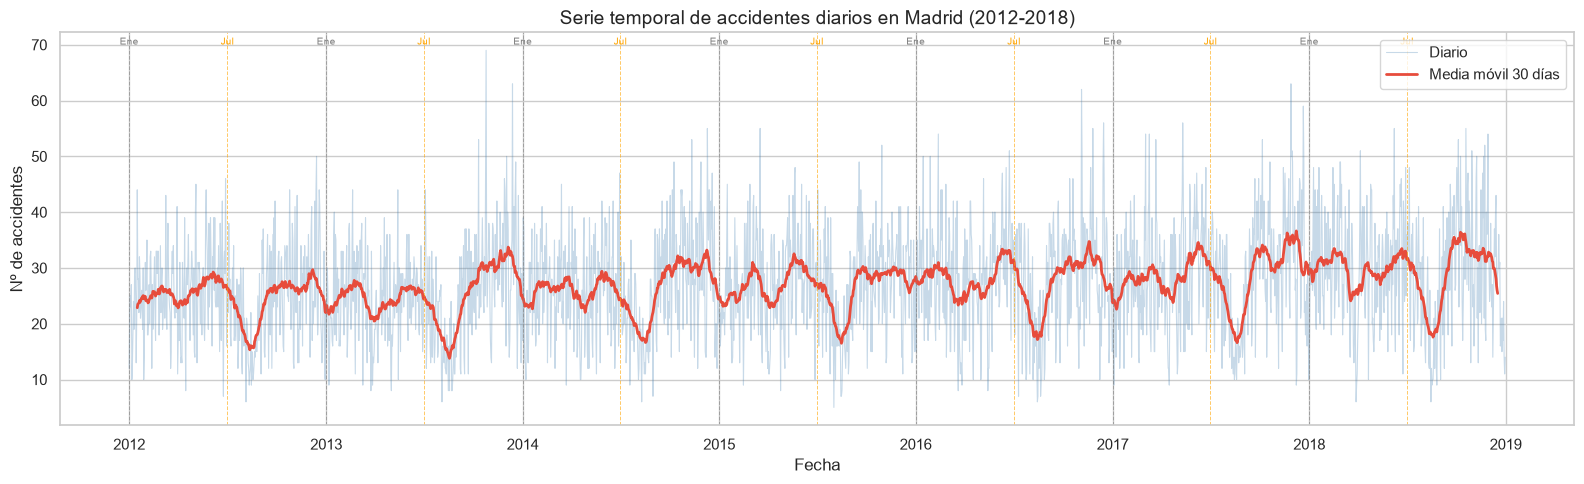

In [96]:
# Serie temporal: accidentes diarios con media móvil de 30 días
serie_temporal = (df.drop_duplicates('Nº PARTE')
                    .groupby('FECHA').size()
                    .reset_index(name='Accidentes'))
serie_temporal['Media_30d'] = serie_temporal['Accidentes'].rolling(30, center=True).mean()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(serie_temporal['FECHA'], serie_temporal['Accidentes'],
        color='steelblue', alpha=0.3, linewidth=0.8, label='Diario')
ax.plot(serie_temporal['FECHA'], serie_temporal['Media_30d'],
        color='#e74c3c', linewidth=2, label='Media móvil 30 días')

# Líneas verticales en enero y julio de cada año
for year in range(2012, 2019):
    ax.axvline(pd.Timestamp(f'{year}-01-01'), color='gray', linestyle='--', linewidth=0.7, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-07-01'), color='orange', linestyle='--', linewidth=0.7, alpha=0.6)
    ax.text(pd.Timestamp(f'{year}-01-01'), ax.get_ylim()[1] * 0.97, 'Ene', fontsize=7, color='gray', ha='center')
    ax.text(pd.Timestamp(f'{year}-07-01'), ax.get_ylim()[1] * 0.97, 'Jul', fontsize=7, color='orange', ha='center')

ax.set_title('Serie temporal de accidentes diarios en Madrid (2012-2018)', fontsize=14)
ax.set_xlabel('Fecha')
ax.set_ylabel('Nº de accidentes')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/05c_serie_temporal.png', dpi=150)
plt.show()

### 📝 Resumen — Sección 3

> - Aunque el número de accidentes registrados va en aumento a lo largo de los años, la proporción entre las diferentes clases de lesividad se mantiene estable.
> - La proporción entre tipos de lesividad también se mantiene entre meses y días de la semana.
> - Los meses con mayor accidentalidad son octubre, noviembre y junio, destacando julio y agosto por su baja siniestralidad probablemente debida al periodo vacacional que va acompañado de una bajada en el tráfico.
> - Los días de la semana con más accidentes son los días laborables, en los que hay más tráfico de la población que se desplaza al trabajo. Durante el fin de semana los accidentes bajan considerablemente.
> - Las franjas horarias con más accidentes son las horas puntas (a las 9h, las 14h y las 17h), coincidiendo con las horas de entrada y salida del trabajo. Como era previsible, las horas nocturnas (de 0h a 7h) cuentan con un volumen mucho más reducido de accidentes.
> - El mapa de calor revela claramente la concentración de accidentes en días laborables durante horas punta, y una mayor dispersión horaria durante el fin de semana. Destaca la alta siniestralidad los viernes entre las 14h y las 16h.
> - Sobre la serie temporal, observamos en la media móvil que la tendencia se mantiene bastante estable entre 20 y 35 accidentes/día durante todo el periodo, lo que sugiere que la accidentalidad en Madrid es estructuralmente constante durante los 7 años analizados. Eso sí, hay una estacionalidad anual muy clara, repitiéndose cada año el mismo patrón: los accidentes caen drásticamente en verano y vuelven a subir en otoño (al haber menos tráfico en vacaciones, hay menos accidentes). Por otra parte, también se identifica un valle en los meses de enero y febrero, seguramente condicionados por las condiciones meteorológicas propias del invierno (como lluvias intensas, nevadas...)

---
## 4. Análisis geográfico

El distrito donde ocurre el accidente puede estar relacionado con factores estructurales como la densidad de tráfico, el tipo de vías o la velocidad permitida. Se analiza tanto el volumen de accidentes como la tasa por habitante para una comparación más justa entre distritos.

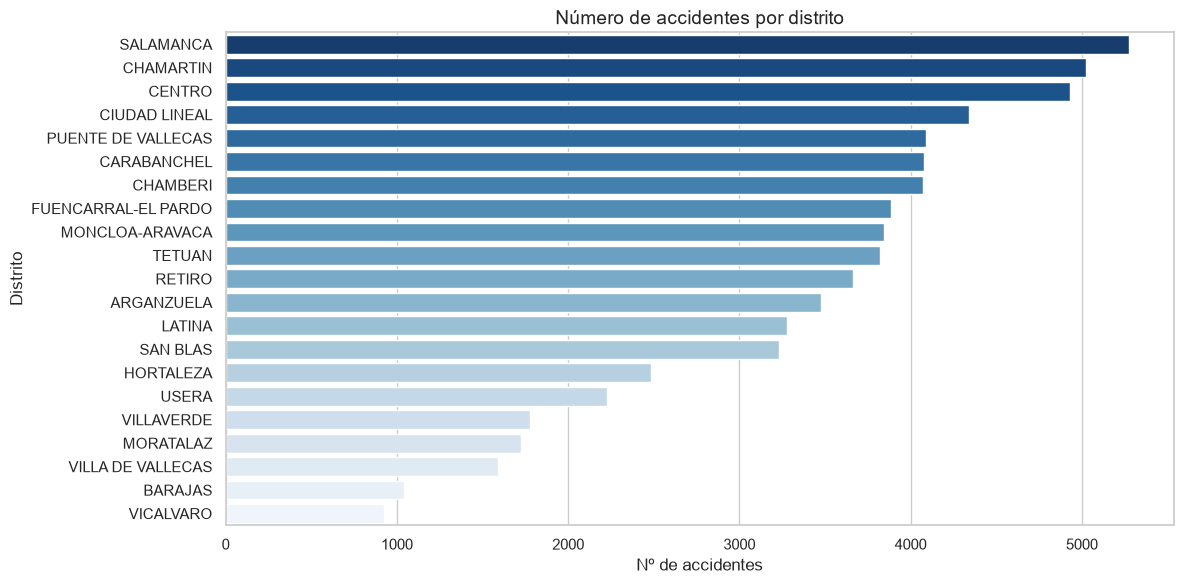

In [97]:
# Limpiar DISTRITO
df['DISTRITO'] = df['DISTRITO'].str.strip()

# Accidentes por distrito
accidentes_distrito = df.drop_duplicates('Nº PARTE').groupby('DISTRITO').size().sort_values(ascending=False).reset_index(name='Accidentes')

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=accidentes_distrito, x='Accidentes', y='DISTRITO', ax=ax, palette='Blues_r')
ax.set_title('Número de accidentes por distrito', fontsize=14)
ax.set_xlabel('Nº de accidentes')
ax.set_ylabel('Distrito')
plt.tight_layout()
plt.savefig('../figures/06_accidentes_por_distrito.png', dpi=150)
plt.show()

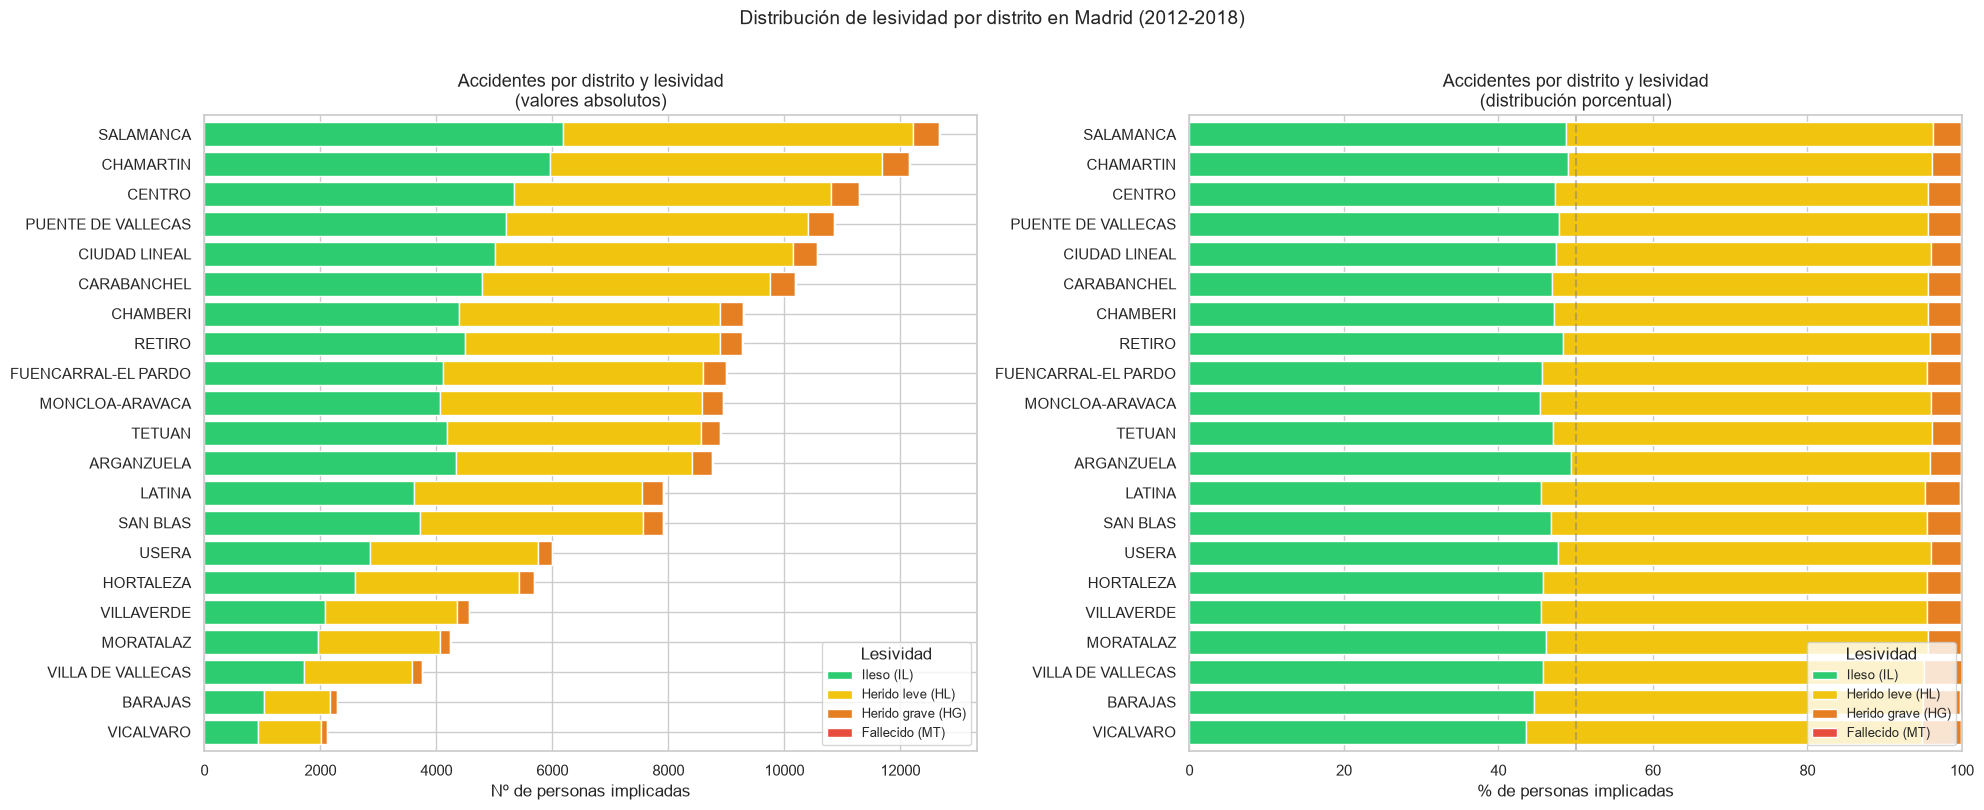

In [117]:
# Lesividad apilada por distrito (absolutos y porcentaje)
lesividad_distrito = (df_sin_na.groupby(['DISTRITO', 'LESIVIDAD'])
                               .size()
                               .unstack(fill_value=0)
                               .reindex(columns=orden_lesividad, fill_value=0))
lesividad_distrito['TOTAL'] = lesividad_distrito.sum(axis=1)
lesividad_distrito = lesividad_distrito.sort_values('TOTAL', ascending=True).drop(columns='TOTAL')
lesividad_pct = lesividad_distrito.div(lesividad_distrito.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

lesividad_distrito.plot(kind='barh', stacked=True, ax=axes[0],
                        color=[colores_lesividad[c] for c in lesividad_distrito.columns], width=0.8)
axes[0].set_title('Accidentes por distrito y lesividad\n(valores absolutos)', fontsize=13)
axes[0].set_xlabel('Nº de personas implicadas')
axes[0].set_ylabel('')
axes[0].legend(title='Lesividad', labels=['Ileso (IL)', 'Herido leve (HL)', 'Herido grave (HG)', 'Fallecido (MT)'],
               loc='lower right', fontsize=9)

lesividad_pct.plot(kind='barh', stacked=True, ax=axes[1],
                   color=[colores_lesividad[c] for c in lesividad_pct.columns], width=0.8)
axes[1].set_title('Accidentes por distrito y lesividad\n(distribución porcentual)', fontsize=13)
axes[1].set_xlabel('% de personas implicadas')
axes[1].set_ylabel('')
axes[1].set_xlim(0, 100)
axes[1].axvline(x=50, color='grey', linestyle='--', alpha=0.5, label='_nolegend_')
axes[1].legend(title='Lesividad', labels=['Ileso (IL)', 'Herido leve (HL)', 'Herido grave (HG)', 'Fallecido (MT)'],
               loc='lower right', fontsize=9)

plt.suptitle('Distribución de lesividad por distrito en Madrid (2012-2018)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../figures/06e_lesividad_por_distrito.png', dpi=150, bbox_inches='tight')
plt.show()

A continuación, se estudia si el número de accidentes tiene relación con la población media por distrito en Madrid durante el periodo estudiado.

In [99]:
# Población media por distrito (media aritmética 2012-2018)
# Fuente: Ayuntamiento de Madrid - Estadística padronal municipal
# Documento disponible en data/raw/poblacion_distritos_madrid.pdf
poblacion_distritos = {
    'CENTRO': 134379, 'ARGANZUELA': 152309, 'RETIRO': 119387,
    'SALAMANCA': 145977, 'CHAMARTIN': 143899, 'TETUAN': 154592,
    'CHAMBERI': 138938, 'FUENCARRAL-EL PARDO': 238485, 'MONCLOA-ARAVACA': 116626,
    'LATINA': 233353, 'CARABANCHEL': 243663, 'USERA': 136491,
    'PUENTE DE VALLECAS': 229315, 'MORATALAZ': 94598, 'CIUDAD LINEAL': 213941,
    'HORTALEZA': 174369, 'VILLAVERDE': 144534, 'VILLA DE VALLECAS': 101411,
    'VICALVARO': 68875, 'SAN BLAS': 156145, 'BARAJAS': 46918
}
N_AÑOS = 7  # 2012 a 2018

accidentes_distrito['Poblacion'] = accidentes_distrito['DISTRITO'].map(poblacion_distritos)
accidentes_distrito['Accidentes_anuales'] = accidentes_distrito['Accidentes'] / N_AÑOS
accidentes_distrito['Tasa_por_100k'] = (accidentes_distrito['Accidentes_anuales'] /
                                         accidentes_distrito['Poblacion'] * 100_000).round(1)
accidentes_distrito = accidentes_distrito.sort_values('Tasa_por_100k', ascending=False)

print(accidentes_distrito[['DISTRITO', 'Accidentes', 'Poblacion', 'Tasa_por_100k']].to_string(index=False))

           DISTRITO  Accidentes  Poblacion  Tasa_por_100k
             CENTRO        4931     134379          524.2
          SALAMANCA        5274     145977          516.1
          CHAMARTIN        5022     143899          498.6
    MONCLOA-ARAVACA        3845     116626          471.0
             RETIRO        3665     119387          438.5
           CHAMBERI        4071     138938          418.6
             TETUAN        3820     154592          353.0
         ARGANZUELA        3476     152309          326.0
            BARAJAS        1043      46918          317.6
           SAN BLAS        3229     156145          295.4
      CIUDAD LINEAL        4341     213941          289.9
          MORATALAZ        1725      94598          260.5
 PUENTE DE VALLECAS        4091     229315          254.9
        CARABANCHEL        4079     243663          239.1
              USERA        2227     136491          233.1
FUENCARRAL-EL PARDO        3884     238485          232.7
  VILLA DE VAL

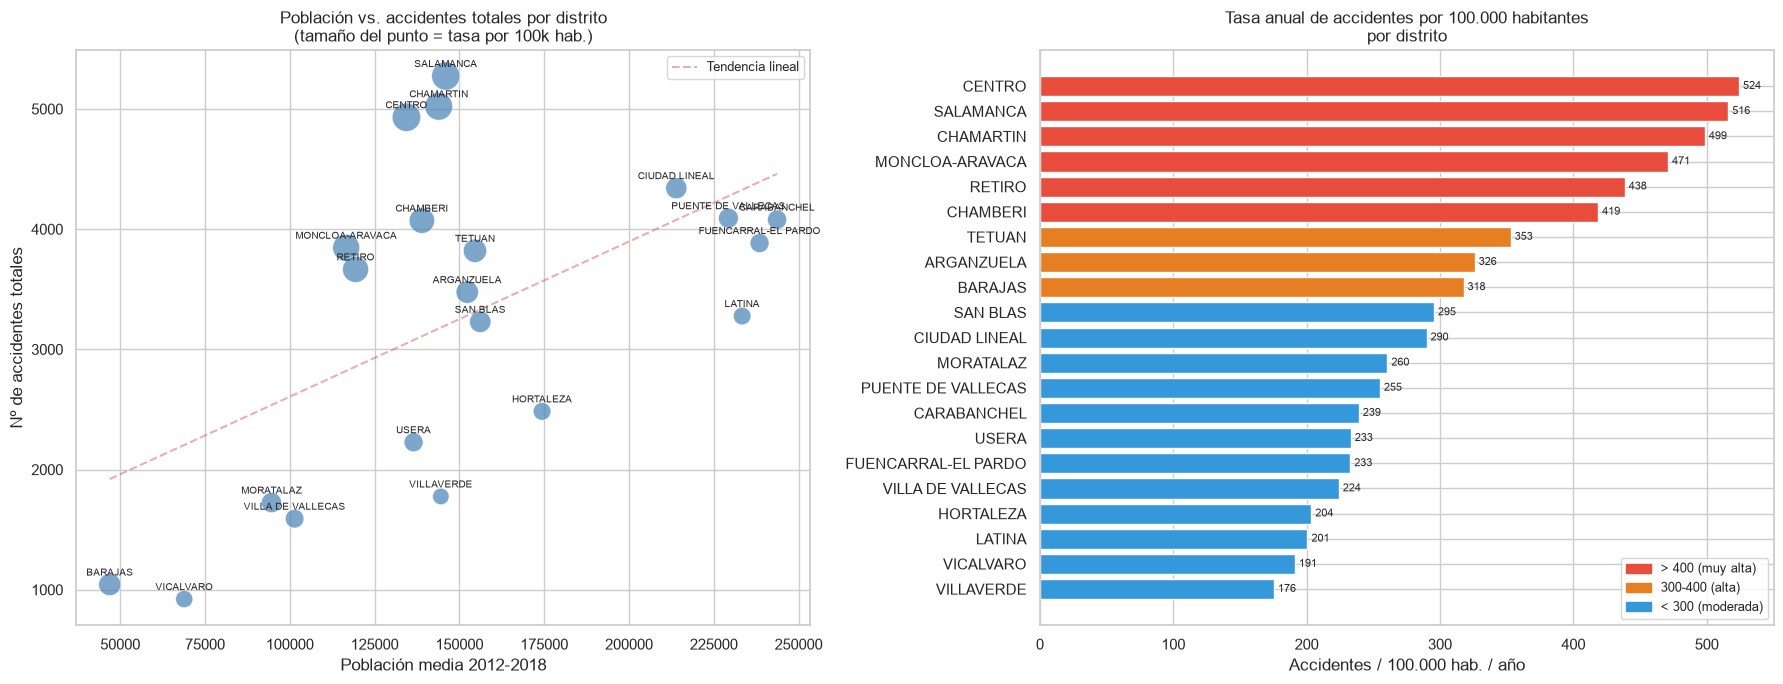

In [100]:
# Scatter: población vs accidentes + ranking por tasa
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax = axes[0]
ax.scatter(accidentes_distrito['Poblacion'], accidentes_distrito['Accidentes'],
           s=accidentes_distrito['Tasa_por_100k'] * 0.8,
           alpha=0.7, color='steelblue', edgecolors='white', linewidth=0.5)
for _, row in accidentes_distrito.iterrows():
    ax.annotate(row['DISTRITO'], (row['Poblacion'], row['Accidentes']),
                fontsize=7, ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')
z = np.polyfit(accidentes_distrito['Poblacion'], accidentes_distrito['Accidentes'], 1)
p = np.poly1d(z)
x_line = np.linspace(accidentes_distrito['Poblacion'].min(), accidentes_distrito['Poblacion'].max(), 100)
ax.plot(x_line, p(x_line), 'r--', alpha=0.5, label='Tendencia lineal')
ax.set_title('Población vs. accidentes totales por distrito\n(tamaño del punto = tasa por 100k hab.)', fontsize=12)
ax.set_xlabel('Población media 2012-2018')
ax.set_ylabel('Nº de accidentes totales')
ax.legend(fontsize=9)

ax2 = axes[1]
datos_ordenados = accidentes_distrito.sort_values('Tasa_por_100k', ascending=True)
colores_tasa = ['#e74c3c' if t > 400 else '#e67e22' if t > 300 else '#3498db'
                for t in datos_ordenados['Tasa_por_100k']]
bars = ax2.barh(datos_ordenados['DISTRITO'], datos_ordenados['Tasa_por_100k'], color=colores_tasa)
ax2.set_title('Tasa anual de accidentes por 100.000 habitantes\npor distrito', fontsize=12)
ax2.set_xlabel('Accidentes / 100.000 hab. / año')
for bar, val in zip(bars, datos_ordenados['Tasa_por_100k']):
    ax2.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
             f'{val:.0f}', va='center', fontsize=8)
from matplotlib.patches import Patch
leyenda = [Patch(color='#e74c3c', label='> 400 (muy alta)'),
           Patch(color='#e67e22', label='300-400 (alta)'),
           Patch(color='#3498db', label='< 300 (moderada)')]
ax2.legend(handles=leyenda, fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('../figures/06c_scatter_poblacion_accidentes.png', dpi=150, bbox_inches='tight')
plt.show()

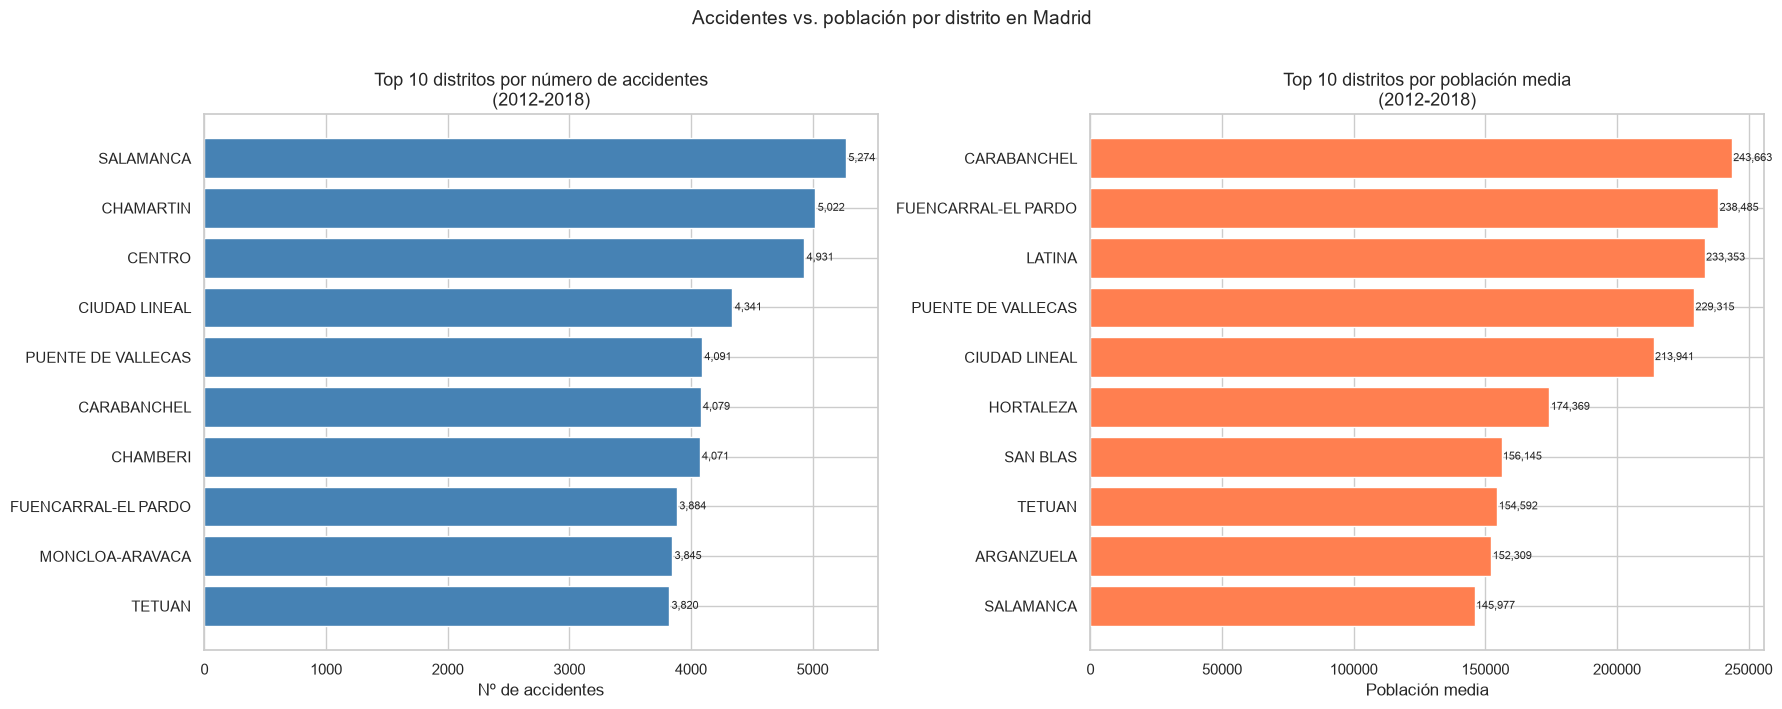

In [102]:
# Ranking accidentes vs población (top 10)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

datos_accidentes = accidentes_distrito.sort_values('Accidentes', ascending=True).tail(10)
axes[0].barh(datos_accidentes['DISTRITO'], datos_accidentes['Accidentes'], color='steelblue')
axes[0].set_title('Top 10 distritos por número de accidentes\n(2012-2018)', fontsize=13)
axes[0].set_xlabel('Nº de accidentes')
for bar, val in zip(axes[0].patches, datos_accidentes['Accidentes']):
    axes[0].text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=8)

datos_poblacion = accidentes_distrito.sort_values('Poblacion', ascending=True).tail(10)
axes[1].barh(datos_poblacion['DISTRITO'], datos_poblacion['Poblacion'], color='coral')
axes[1].set_title('Top 10 distritos por población media\n(2012-2018)', fontsize=13)
axes[1].set_xlabel('Población media')
for bar, val in zip(axes[1].patches, datos_poblacion['Poblacion']):
    axes[1].text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=8)

plt.suptitle('Accidentes vs. población por distrito en Madrid', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../figures/06d_ranking_accidentes_vs_poblacion.png', dpi=150, bbox_inches='tight')
plt.show()

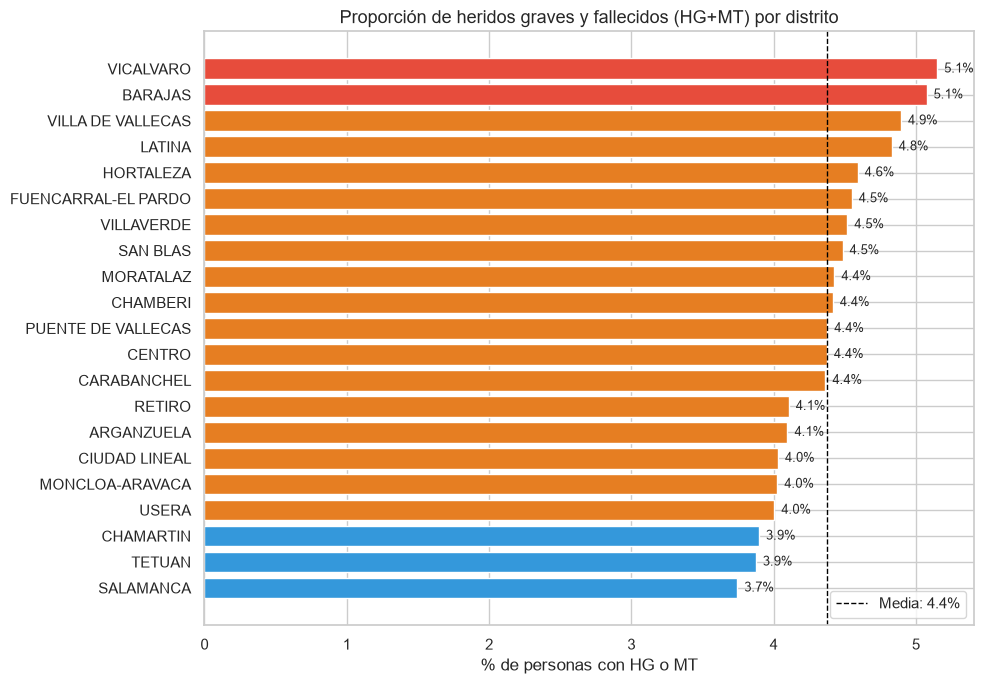

In [103]:
# Proporción de HG+MT por distrito
gravedad_distrito = df_sin_na.groupby('DISTRITO')['GRAVE'].mean().mul(100).reset_index(name='Pct_HG_MT')
gravedad_distrito = gravedad_distrito.sort_values('Pct_HG_MT', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colores = ['#e74c3c' if v > 5 else '#e67e22' if v > 4 else '#3498db'
           for v in gravedad_distrito['Pct_HG_MT']]
bars = ax.barh(gravedad_distrito['DISTRITO'], gravedad_distrito['Pct_HG_MT'], color=colores)

for bar, val in zip(bars, gravedad_distrito['Pct_HG_MT']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

ax.axvline(gravedad_distrito['Pct_HG_MT'].mean(), color='black', linestyle='--',
           linewidth=1, label=f'Media: {gravedad_distrito["Pct_HG_MT"].mean():.1f}%')

ax.set_title('Proporción de heridos graves y fallecidos (HG+MT) por distrito', fontsize=13)
ax.set_xlabel('% de personas con HG o MT')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/06f_pct_graves_por_distrito.png', dpi=150)
plt.show()

Observando los resultados anteriores, podemos ver que una población más alta no se relaciona con tasas más altas de accidentes. Salamanca, Chamartín y Centro son los distritos con más accidentes, mientras que ocupan las posiciones 10, 12 y 15 en población, respectivamente. Esto nos conduce a pensar que los accidentes se concentran en los distritos con más volumen de tráfico de paso y no de población residente.

### 📝 Resumen — Sección 4
 
> - Hay una correlación positiva general entre el volúmen de población y el número de accidentes, pero con muchas excepciones relevantes. Salamanca, Chamartín y Centro tienen muchos más accidentes de los que su población haría esperar. Son distritos con población media-baja pero puntos grandes, lo que confirma que su tasa por 100.ooo habitantes es muy alta (alrededor de 500). Esto apunta al tráfico de paso como factor clave. Por otra banda, Latina, Fuencarral-El Pardo, Carabanchel y Puente de Vallecas tienen poblaciones altas pero menos accidentes de los esperados. Son distritos periféricos con menor tráfico de paso y puntos pequeños.
> - Al normalizar por población, el ranking confirma que Centro, Salamanca y Chamartín tienen tasas superiores a 490 accidentes/100k hab/año, más del doble que distritos periféricos como Villaverde o Vicálvaro.
> - Esto sugiere que el volumen de tráfico de paso, y no la población residente, es el factor determinante en la accidentalidad por distrito.
> - Los distritos con mayor proporción de accidentes graves (que incluyen heridos graves o fallecidos) son Villad de Vallecas, Vicalvaro y Barajas, que no coinciden con los distritos con más accidentalidad. 

---
## 5. Condiciones del accidente

En esta sección se analizan las variables relacionadas con el contexto en el que ocurrió el accidente: tipo de accidente, condiciones meteorológicas y estado del firme. Estas variables son candidatas clave para el modelo predictivo. Se analiza no solo su frecuencia, sino también su relación con la gravedad del accidente.

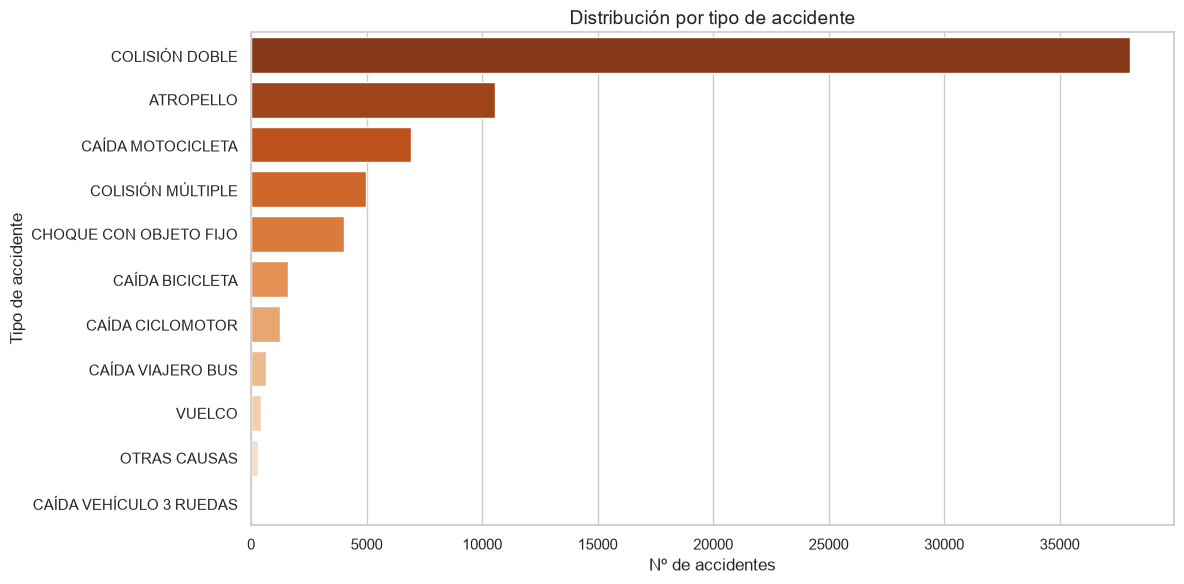

         TIPO ACCIDENTE  Accidentes  Porcentaje (%)
         COLISIÓN DOBLE       38047           55.32
              ATROPELLO       10564           15.36
      CAÍDA MOTOCICLETA        6907           10.04
      COLISIÓN MÚLTIPLE        4988            7.25
 CHOQUE CON OBJETO FIJO        4041            5.88
        CAÍDA BICICLETA        1583            2.30
       CAÍDA CICLOMOTOR        1272            1.85
      CAÍDA VIAJERO BUS         650            0.95
                 VUELCO         426            0.62
           OTRAS CAUSAS         289            0.42
CAÍDA VEHÍCULO 3 RUEDAS           6            0.01


In [104]:
# Tipo de accidente
df['TIPO ACCIDENTE'] = df['TIPO ACCIDENTE'].str.strip()
tipo_accidente = df.drop_duplicates('Nº PARTE').groupby('TIPO ACCIDENTE').size().sort_values(ascending=False).reset_index(name='Accidentes')
tipo_accidente['Porcentaje (%)'] = (tipo_accidente['Accidentes'] / tipo_accidente['Accidentes'].sum() * 100).round(2)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=tipo_accidente, x='Accidentes', y='TIPO ACCIDENTE', ax=ax, palette='Oranges_r')
ax.set_title('Distribución por tipo de accidente', fontsize=14)
ax.set_xlabel('Nº de accidentes')
ax.set_ylabel('Tipo de accidente')
plt.tight_layout()
plt.savefig('../figures/07_tipo_accidente.png', dpi=150)
plt.show()

print(tipo_accidente.to_string(index=False))

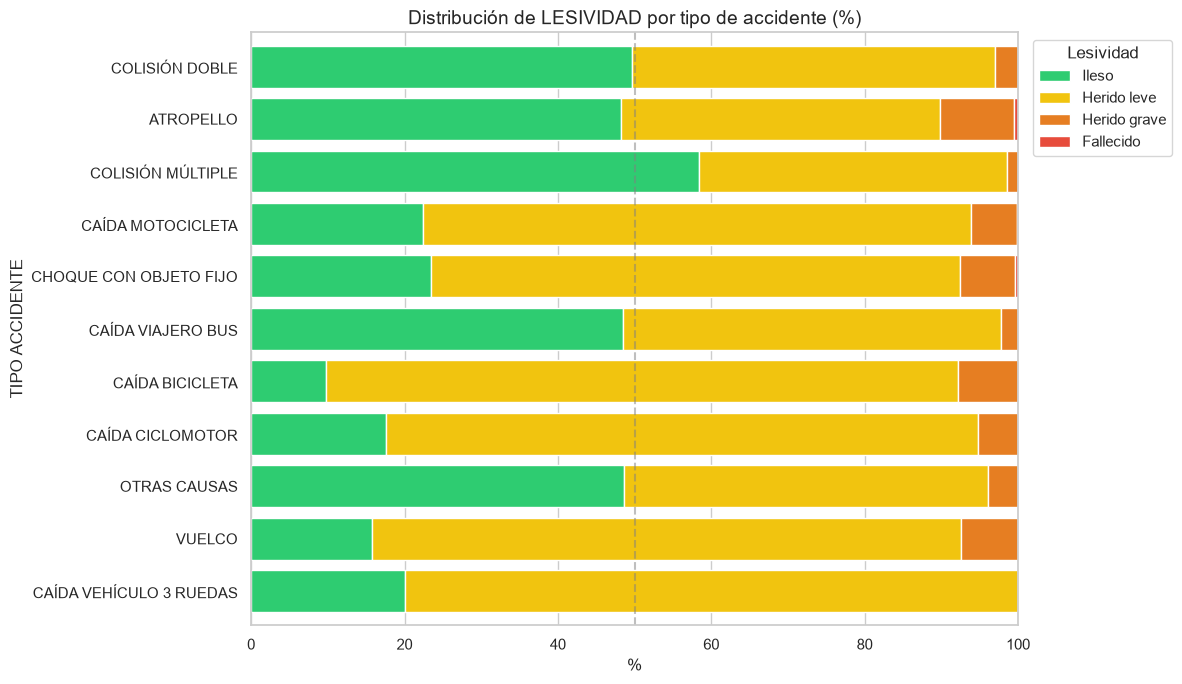

In [116]:
# LESIVIDAD por tipo de accidente — ¿qué tipos son más graves?
lesividad_tipo_acc = (df_sin_na.groupby(['TIPO ACCIDENTE', 'LESIVIDAD'])
                               .size()
                               .unstack(fill_value=0)
                               .reindex(columns=orden_lesividad, fill_value=0))
lesividad_tipo_acc['TOTAL'] = lesividad_tipo_acc.sum(axis=1)
lesividad_tipo_acc = lesividad_tipo_acc.sort_values('TOTAL', ascending=True).drop(columns='TOTAL')
lesividad_tipo_acc_pct = lesividad_tipo_acc.div(lesividad_tipo_acc.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 7))
lesividad_tipo_acc_pct[orden_lesividad].plot(kind='barh', stacked=True, ax=ax,
                             color=[colores_lesividad[c] for c in orden_lesividad], width=0.8)
ax.set_title('Distribución de LESIVIDAD por tipo de accidente (%)', fontsize=14)
ax.set_xlabel('%')
ax.set_xlim(0, 100)
ax.axvline(50, color='grey', linestyle='--', alpha=0.5, label='_nolegend_')
ax.legend(title='Lesividad', labels=['Ileso', 'Herido leve', 'Herido grave', 'Fallecido'],
          bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../figures/07b_lesividad_por_tipo_accidente.png', dpi=150, bbox_inches='tight')
plt.show()

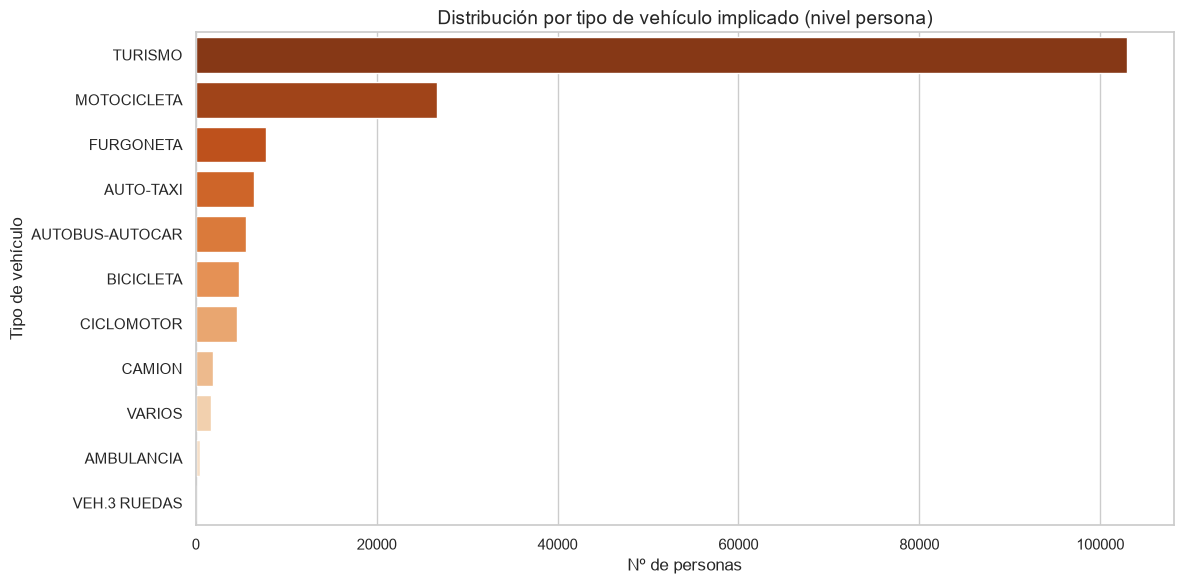

  Tipo Vehiculo  Personas  Porcentaje (%)
        TURISMO    103004           63.35
    MOTOCICLETA     26704           16.42
      FURGONETA      7756            4.77
      AUTO-TAXI      6412            3.94
AUTOBUS-AUTOCAR      5519            3.39
      BICICLETA      4741            2.92
     CICLOMOTOR      4503            2.77
         CAMION      1863            1.15
         VARIOS      1638            1.01
     AMBULANCIA       407            0.25
   VEH.3 RUEDAS        43            0.03


In [106]:
# Distribución por tipo de vehículo implicado (nivel persona, excluye NO ASIGNADO)
tipo_vehiculo = (df[df['Tipo Vehiculo'] != 'NO ASIGNADO']
                   .groupby('Tipo Vehiculo').size()
                   .sort_values(ascending=False)
                   .reset_index(name='Personas'))
tipo_vehiculo['Porcentaje (%)'] = (tipo_vehiculo['Personas'] / tipo_vehiculo['Personas'].sum() * 100).round(2)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=tipo_vehiculo, x='Personas', y='Tipo Vehiculo', ax=ax, palette='Oranges_r')
ax.set_title('Distribución por tipo de vehículo implicado (nivel persona)', fontsize=14)
ax.set_xlabel('Nº de personas')
ax.set_ylabel('Tipo de vehículo')
plt.tight_layout()
plt.savefig('../figures/07b_tipo_vehiculo.png', dpi=150)
plt.show()

print(tipo_vehiculo.to_string(index=False))

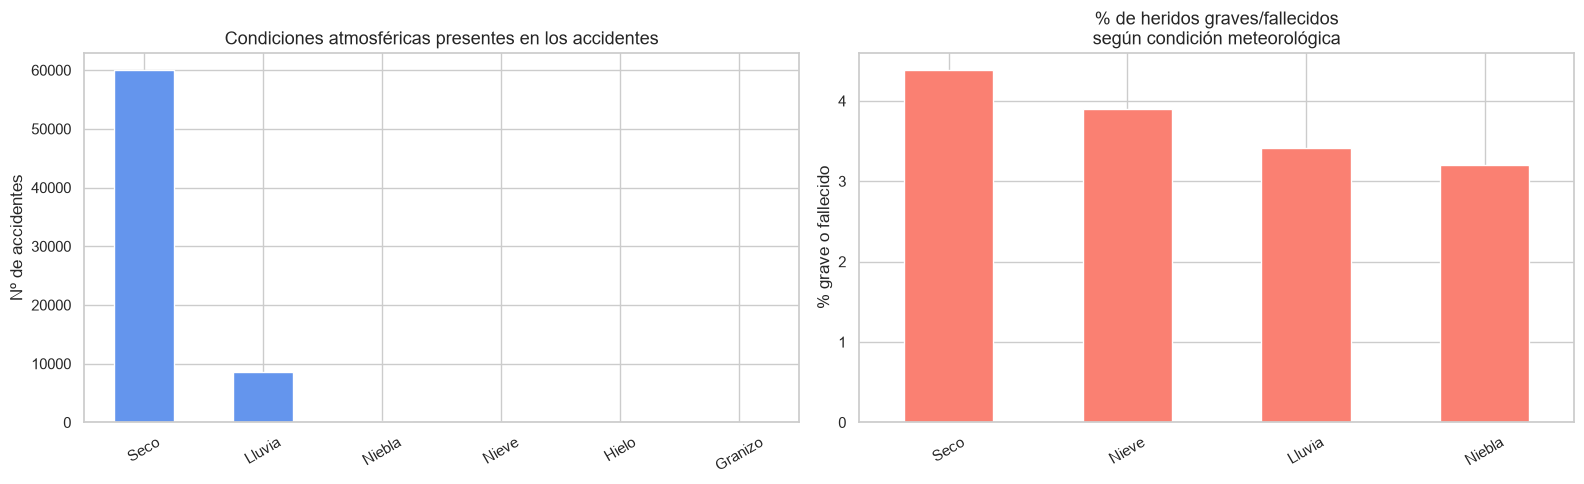

        Nº accidentes Porcentaje (%)  % graves
Granizo             9           0.01       NaN
Hielo              65           0.09       NaN
Lluvia           8535          12.41      3.41
Niebla            188           0.27      3.20
Nieve              68            0.1      3.90
Seco            59975          87.21      4.38


In [108]:
# Condiciones meteorológicas (CPFA) — frecuencia y tasa de gravedad
cols_cpfa = [c for c in df.columns if c.startswith('CPFA')]

df_acc = df.drop_duplicates('Nº PARTE')  # nivel accidente
cpfa_df = df_acc[cols_cpfa].apply(lambda x: x.str.strip()).replace({'SI': 1, 'NO': 0})
cpfa_counts = cpfa_df.sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

cpfa_counts.plot(kind='bar', ax=axes[0], color='cornflowerblue')
axes[0].set_title('Condiciones atmosféricas presentes en los accidentes', fontsize=13)
axes[0].set_xticklabels([c.replace('CPFA ', '') for c in cpfa_counts.index], rotation=30)
axes[0].set_ylabel('Nº de accidentes')

tasas_graves_cpfa = {}
for col in cols_cpfa:
    nombre = col.replace('CPFA ', '')
    mask = df_sin_na[col].str.strip() == 'SI'
    if mask.sum() > 100:
        tasas_graves_cpfa[nombre] = df_sin_na.loc[mask, 'GRAVE'].mean() * 100

pd.Series(tasas_graves_cpfa).sort_values(ascending=False).plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('% de heridos graves/fallecidos\nsegún condición meteorológica', fontsize=13)
axes[1].set_ylabel('% grave o fallecido')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../figures/08_condiciones_atmosfericas.png', dpi=150)
plt.show()

# Tabla resumen
tabla_cpfa = pd.DataFrame({
    'Nº accidentes': cpfa_counts,
    'Porcentaje (%)': (cpfa_counts / len(df_acc) * 100).round(2),
    '% graves': pd.Series({f'CPFA {k}': v for k, v in tasas_graves_cpfa.items()}).round(2)
})
tabla_cpfa.index = [i.replace('CPFA ', '') for i in tabla_cpfa.index]
print(tabla_cpfa.to_string())


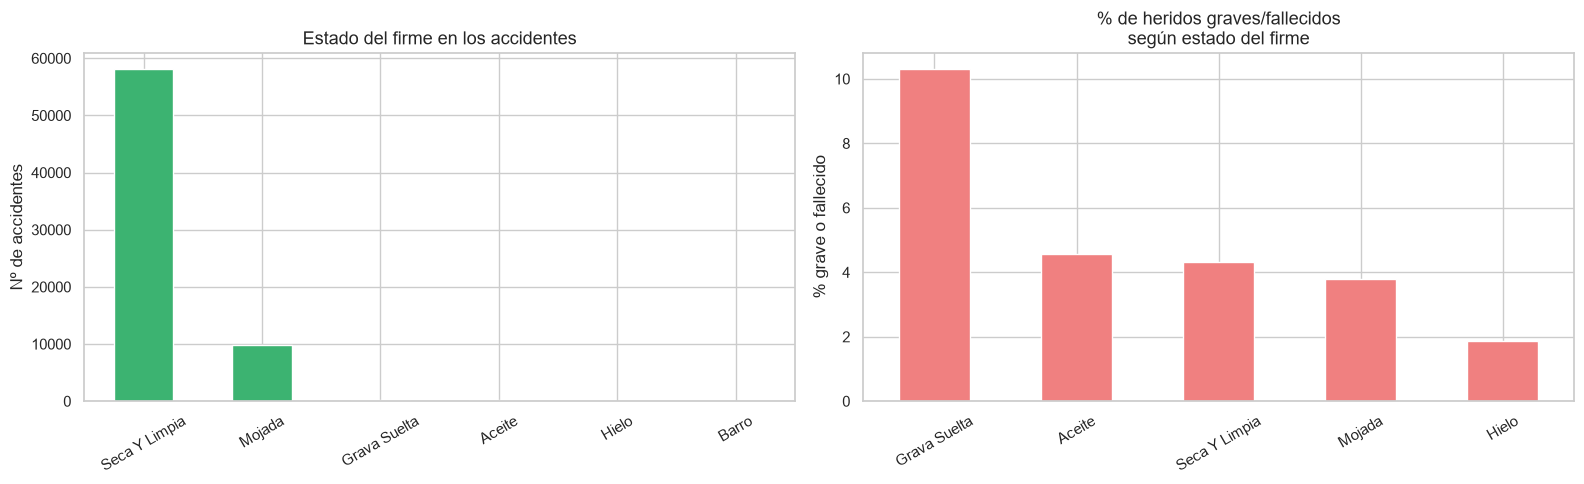

              Nº accidentes Porcentaje (%)  % graves
Aceite                  260           0.38      4.57
Barro                    59           0.09       NaN
Grava Suelta            273            0.4     10.30
Hielo                   102           0.15      1.85
Mojada                 9828          14.29      3.78
Seca Y Limpia         58073          84.44      4.32


In [109]:
# Estado del firme (CPSV) — frecuencia y tasa de gravedad
cols_cpsv = [c for c in df.columns if c.startswith('CPSV')]

df_acc = df.drop_duplicates('Nº PARTE')  # nivel accidente
cpsv_df = df_acc[cols_cpsv].apply(lambda x: x.str.strip()).replace({'SI': 1, 'NO': 0})
cpsv_counts = cpsv_df.sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

cpsv_counts.plot(kind='bar', ax=axes[0], color='mediumseagreen')
axes[0].set_title('Estado del firme en los accidentes', fontsize=13)
axes[0].set_xticklabels([c.replace('CPSV ', '') for c in cpsv_counts.index], rotation=30)
axes[0].set_ylabel('Nº de accidentes')

tasas_graves_cpsv = {}
for col in cols_cpsv:
    nombre = col.replace('CPSV ', '')
    mask = df_sin_na[col].str.strip() == 'SI'
    if mask.sum() > 100:
        tasas_graves_cpsv[nombre] = df_sin_na.loc[mask, 'GRAVE'].mean() * 100

pd.Series(tasas_graves_cpsv).sort_values(ascending=False).plot(kind='bar', ax=axes[1], color='lightcoral')
axes[1].set_title('% de heridos graves/fallecidos\nsegún estado del firme', fontsize=13)
axes[1].set_ylabel('% grave o fallecido')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../figures/09_estado_firme.png', dpi=150)
plt.show()

# Tabla resumen
tabla_cpsv = pd.DataFrame({
    'Nº accidentes': cpsv_counts,
    'Porcentaje (%)': (cpsv_counts / len(df_acc) * 100).round(2),
    '% graves': pd.Series({f'CPSV {k}': v for k, v in tasas_graves_cpsv.items()}).round(2)
})
tabla_cpsv.index = [i.replace('CPSV ', '') for i in tabla_cpsv.index]
print(tabla_cpsv.to_string())

### 📝 Resumen — Sección 5

> - El tipo de accidente más frecuente es colisión doble, representando más de la mitad del total de accidentes, y seguido por atropello y caída motocicleta
> - No obstante, el tipo de accidente que mayor proporción de graves tiene es caída bicicleta.
> - Por tipo de vehículo implicado, hay turismo, motocicleta y furgoneta.
> - La condición meteorológica más común es seco, lo cual es coherente con el clima de Madrid. Sin embargo, la tasa de graves es mayor cuando nieva o llueve.
> - El estado del firme con mayor tasa de accidentes graves es "seca y limpia". Aún así, la tasa de gravedad aumenta brutalmente cuando encontramos grava suelta y aceite en la vía.

---
## 6. Perfil de los implicados

El perfil de las personas implicadas en el accidente (su rol, sexo, edad y tipo de vehículo) puede estar relacionado con la gravedad de las consecuencias. Se analiza también la tasa de gravedad según la franja horaria y el número de víctimas por accidente.

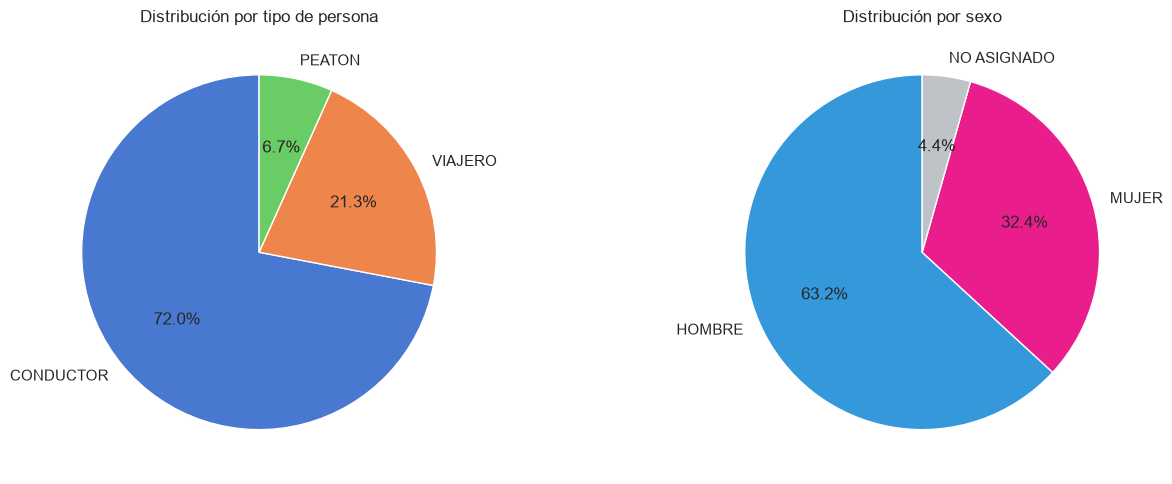

In [63]:
# Limpiar columnas de perfil
df['SEXO'] = df['SEXO'].str.strip()
df['Tramo Edad'] = df['Tramo Edad'].str.strip()
df['Tipo Vehiculo'] = df['Tipo Vehiculo'].str.strip()

# Distribución por tipo de persona y sexo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tipo_persona_counts = df['TIPO PERSONA'].value_counts()
axes[0].pie(tipo_persona_counts.values, labels=tipo_persona_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Distribución por tipo de persona')

sexo_counts = df['SEXO'].value_counts()
axes[1].pie(sexo_counts.values, labels=sexo_counts.index, autopct='%1.1f%%', startangle=90,
            colors=['#3498db', '#e91e8c', '#bdc3c7'])
axes[1].set_title('Distribución por sexo')

plt.tight_layout()
plt.savefig('../figures/10_perfil_implicados.png', dpi=150)
plt.show()

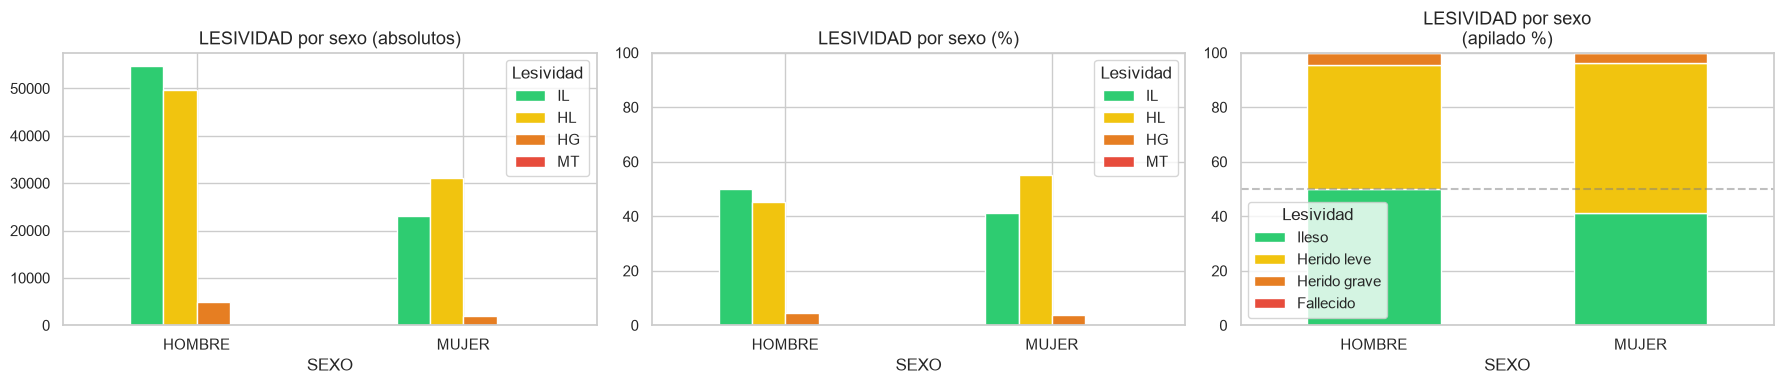

In [120]:
# LESIVIDAD por sexo
lesividad_sexo = (df_sin_na[df_sin_na['SEXO'].isin(['HOMBRE', 'MUJER'])]
                  .groupby(['SEXO', 'LESIVIDAD']).size()
                  .unstack(fill_value=0)
                  .reindex(columns=orden_lesividad, fill_value=0))
lesividad_sexo_pct = lesividad_sexo.div(lesividad_sexo.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

lesividad_sexo.plot(kind='bar', ax=axes[0], color=[colores_lesividad[c] for c in orden_lesividad], edgecolor='white')
axes[0].set_title('LESIVIDAD por sexo (absolutos)', fontsize=13)
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Lesividad')

lesividad_sexo_pct.plot(kind='bar', ax=axes[1], color=[colores_lesividad[c] for c in orden_lesividad], edgecolor='white')
axes[1].set_title('LESIVIDAD por sexo (%)', fontsize=13)
axes[1].tick_params(axis='x', rotation=0)
axes[1].set_ylim(0, 100)
axes[1].legend(title='Lesividad')

lesividad_sexo_pct.plot(kind='bar', stacked=True, ax=axes[2], color=[colores_lesividad[c] for c in orden_lesividad], edgecolor='white')
axes[2].set_title('LESIVIDAD por sexo\n(apilado %)', fontsize=13)
axes[2].tick_params(axis='x', rotation=0)
axes[2].set_ylim(0, 100)
axes[2].axhline(50, color='grey', linestyle='--', alpha=0.5, label='_nolegend_')
axes[2].legend(title='Lesividad', labels=['Ileso', 'Herido leve', 'Herido grave', 'Fallecido'])

plt.tight_layout()
plt.savefig('../figures/10b_lesividad_por_sexo.png', dpi=150)
plt.show()

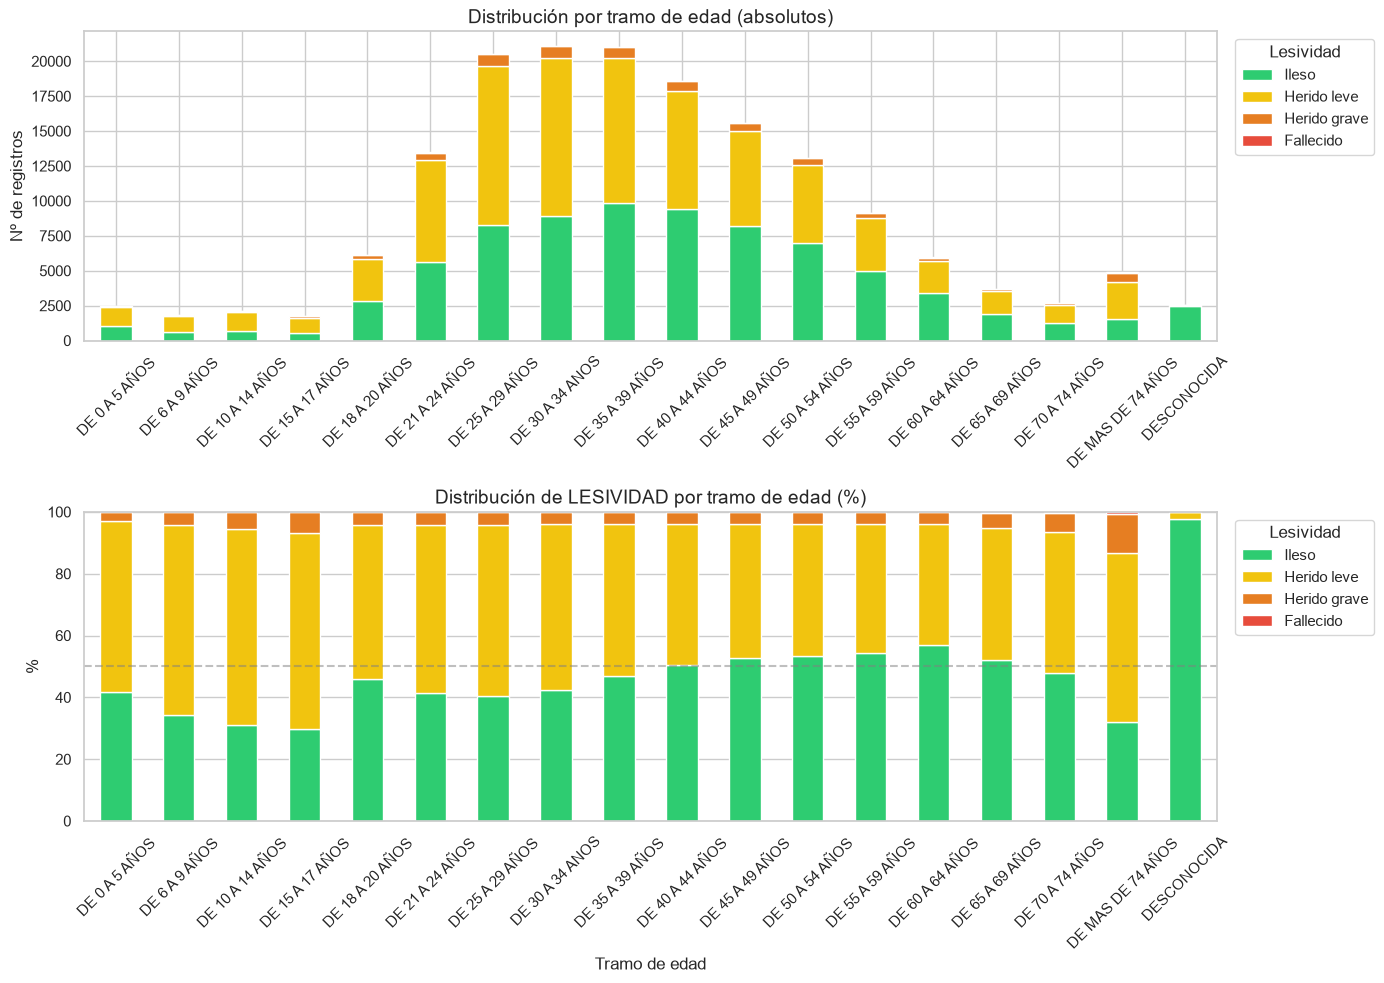

In [123]:
# Distribución por tramo de edad
orden_edad = [
    'DE 0 A 5 AÑOS', 'DE 6 A 9 AÑOS', 'DE 10 A 14 AÑOS', 'DE 15 A 17 AÑOS',
    'DE 18 A 20 AÑOS', 'DE 21 A 24 AÑOS', 'DE 25 A 29 AÑOS', 'DE 30 A 34 ANOS',
    'DE 35 A 39 AÑOS', 'DE 40 A 44 AÑOS', 'DE 45 A 49 AÑOS', 'DE 50 A 54 AÑOS',
    'DE 55 A 59 AÑOS', 'DE 60 A 64 AÑOS', 'DE 65 A 69 AÑOS', 'DE 70 A 74 AÑOS',
    'DE MAS DE 74 AÑOS', 'DESCONOCIDA'
]

lesividad_edad = (df_sin_na.groupby(['Tramo Edad', 'LESIVIDAD'])
                           .size()
                           .unstack(fill_value=0)
                           .reindex(index=orden_edad, columns=orden_lesividad, fill_value=0))
lesividad_edad_pct = lesividad_edad.div(lesividad_edad.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Distribución absoluta apilada por lesividad
lesividad_edad.plot(kind='bar', stacked=True, ax=axes[0],
                    color=[colores_lesividad[c] for c in orden_lesividad], edgecolor='white')
axes[0].set_title('Distribución por tramo de edad (absolutos)', fontsize=14)
axes[0].set_xlabel('')
axes[0].set_ylabel('Nº de registros')
axes[0].legend(title='Lesividad', labels=['Ileso', 'Herido leve', 'Herido grave', 'Fallecido'],
               bbox_to_anchor=(1.01, 1), loc='upper left')
axes[0].tick_params(axis='x', rotation=45)

# Apilado por lesividad (%)
lesividad_edad_pct.plot(kind='bar', stacked=True, ax=axes[1],
                        color=[colores_lesividad[c] for c in orden_lesividad], edgecolor='white')
axes[1].set_title('Distribución de LESIVIDAD por tramo de edad (%)', fontsize=14)
axes[1].set_xlabel('Tramo de edad')
axes[1].set_ylabel('%')
axes[1].set_ylim(0, 100)
axes[1].axhline(50, color='grey', linestyle='--', alpha=0.5, label='_nolegend_')
axes[1].legend(title='Lesividad', labels=['Ileso', 'Herido leve', 'Herido grave', 'Fallecido'],
               bbox_to_anchor=(1.01, 1), loc='upper left')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../figures/11_tramo_edad.png', dpi=150, bbox_inches='tight')
plt.show()

Distribución de LESIVIDAD por tipo de persona (%):
LESIVIDAD       HG    HL    IL   MT  NO ASIGNADA
TIPO PERSONA                                    
CONDUCTOR      3.2  41.8  48.7  0.1          6.3
PEATON        19.0  78.0   2.1  0.9          0.0
VIAJERO        1.9  51.8  46.3  0.0          0.0
['HG', 'HL', 'IL', 'MT', 'NO ASIGNADA']


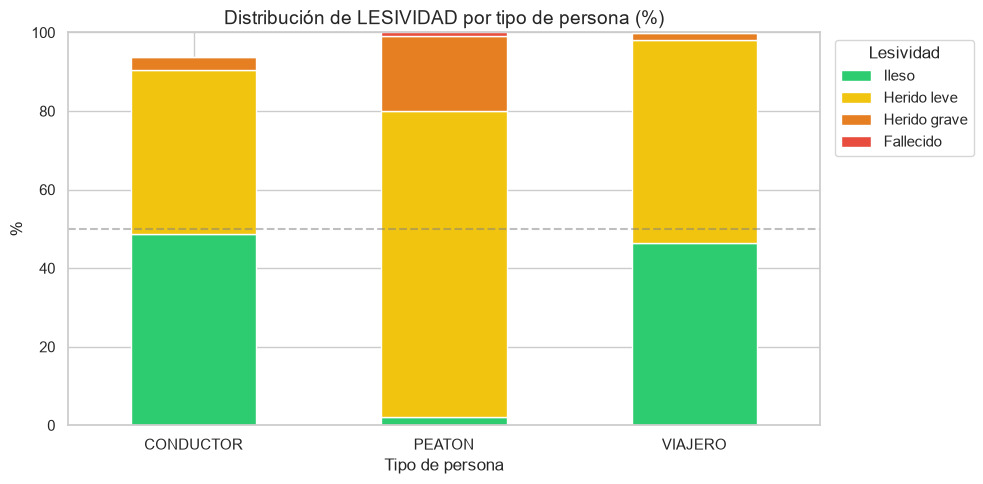

In [124]:
# Relación entre LESIVIDAD y tipo de persona
lesividad_tipo = pd.crosstab(df['TIPO PERSONA'], df['LESIVIDAD'], normalize='index') * 100

print('Distribución de LESIVIDAD por tipo de persona (%):')
print(lesividad_tipo.round(1))

print(lesividad_tipo.columns.tolist())
fig, ax = plt.subplots(figsize=(10, 5))
lesividad_tipo[orden_lesividad].plot(kind='bar', stacked=True, ax=ax,
                                      color=[colores_lesividad[c] for c in orden_lesividad],
                                      edgecolor='white')
ax.set_title('Distribución de LESIVIDAD por tipo de persona (%)', fontsize=14)
ax.set_xlabel('Tipo de persona')
ax.set_ylabel('%')
ax.set_ylim(0, 100)
ax.axhline(50, color='grey', linestyle='--', alpha=0.5, label='_nolegend_')
ax.legend(title='Lesividad', labels=['Ileso', 'Herido leve', 'Herido grave', 'Fallecido'],
          bbox_to_anchor=(1.01, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('../figures/10c_lesividad_por_tipo_persona.png', dpi=150, bbox_inches='tight')
plt.show()

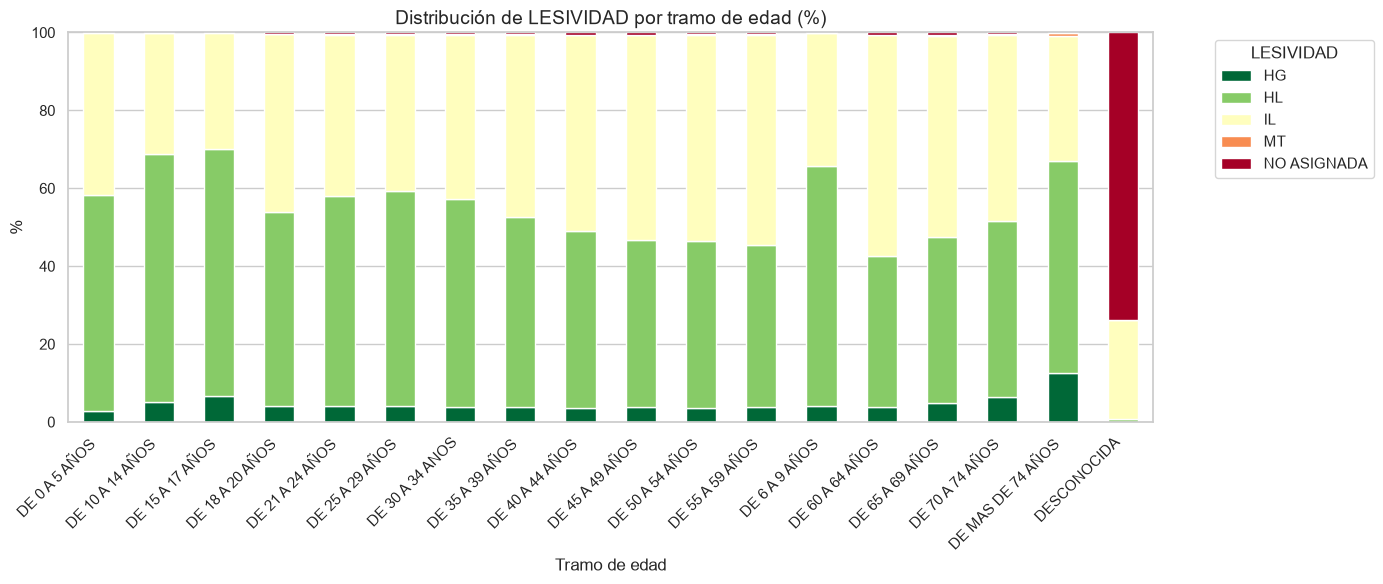

In [69]:
# Relación entre LESIVIDAD y tramo de edad
lesividad_edad = pd.crosstab(df['Tramo Edad'], df['LESIVIDAD'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(14, 6))
lesividad_edad.plot(kind='bar', stacked=True, ax=ax, colormap='RdYlGn_r')
ax.set_title('Distribución de LESIVIDAD por tramo de edad (%)', fontsize=14)
ax.set_xlabel('Tramo de edad')
ax.set_ylabel('%')
ax.legend(title='LESIVIDAD', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../figures/12_lesividad_por_edad.png', dpi=150)
plt.show()

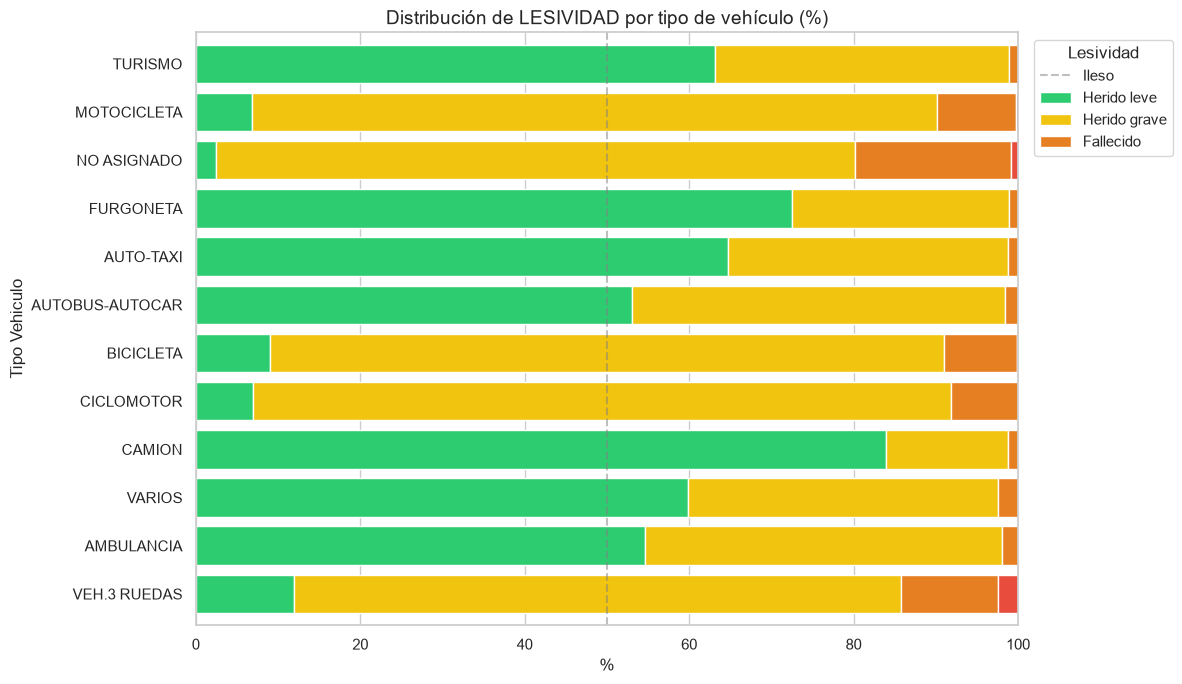

In [125]:
# LESIVIDAD por tipo de vehículo (top 12)
top_vehiculos = df['Tipo Vehiculo'].value_counts().head(12).index
df_veh = df_sin_na[df_sin_na['Tipo Vehiculo'].isin(top_vehiculos)]

lesividad_vehiculo = (df_veh.groupby(['Tipo Vehiculo', 'LESIVIDAD'])
                             .size().unstack(fill_value=0)
                             .reindex(columns=orden_lesividad, fill_value=0))
lesividad_vehiculo['TOTAL'] = lesividad_vehiculo.sum(axis=1)
lesividad_vehiculo = lesividad_vehiculo.sort_values('TOTAL', ascending=True).drop(columns='TOTAL')
lesividad_vehiculo_pct = lesividad_vehiculo.div(lesividad_vehiculo.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 7))
lesividad_vehiculo_pct.plot(kind='barh', stacked=True, ax=ax,
                             color=[colores_lesividad[c] for c in orden_lesividad], width=0.8)
ax.set_title('Distribución de LESIVIDAD por tipo de vehículo (%)', fontsize=14)
ax.set_xlabel('%')
ax.set_xlim(0, 100)
ax.axvline(50, color='grey', linestyle='--', alpha=0.5)
ax.legend(title='Lesividad', labels=['Ileso', 'Herido leve', 'Herido grave', 'Fallecido'],
          bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../figures/13_lesividad_por_vehiculo.png', dpi=150, bbox_inches='tight')
plt.show()

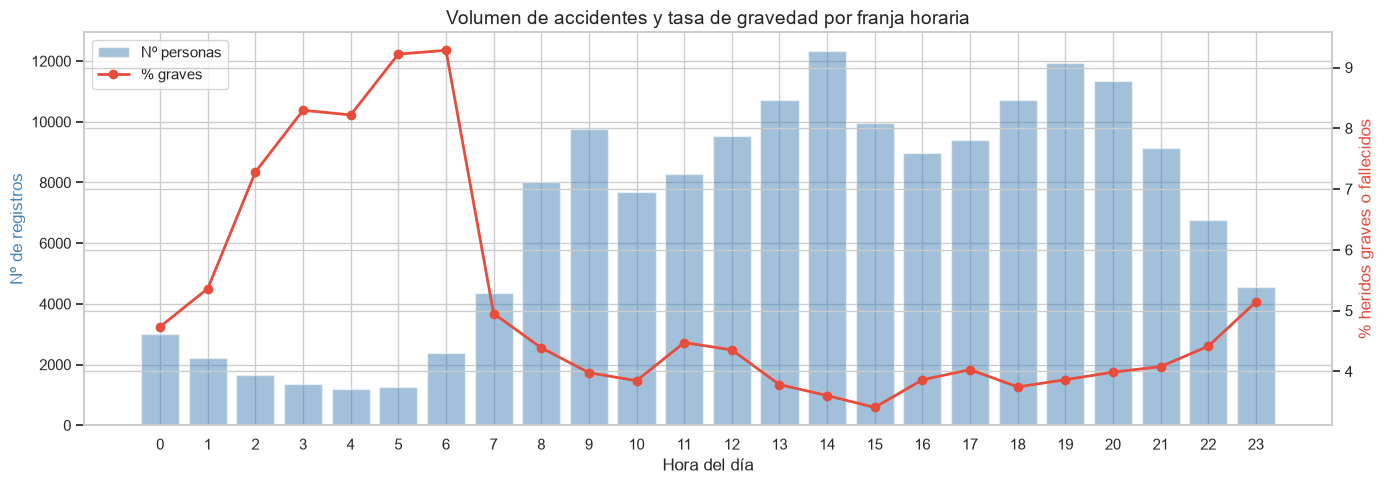

In [126]:
# Gráfico dual: volumen de accidentes y tasa de gravedad por franja horaria
df_hora = df_sin_na.copy()
df_hora['HORA'] = df_hora['RANGO HORARIO'].str.extract(r'(\d+)').astype(float)

tasa_grave_hora = df_hora.groupby('HORA')['GRAVE'].mean() * 100
accidentes_hora_n = df_hora.groupby('HORA').size()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.bar(accidentes_hora_n.index, accidentes_hora_n.values, color='steelblue', alpha=0.5, label='Nº personas')
ax2.plot(tasa_grave_hora.index, tasa_grave_hora.values, color='#e74c3c', marker='o', linewidth=2, label='% graves')

ax1.set_xlabel('Hora del día')
ax1.set_ylabel('Nº de registros', color='steelblue')
ax2.set_ylabel('% heridos graves o fallecidos', color='#e74c3c')
ax1.set_title('Volumen de accidentes y tasa de gravedad por franja horaria', fontsize=14)
ax1.set_xticks(range(0, 24))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('../figures/14_gravedad_por_hora.png', dpi=150)
plt.show()

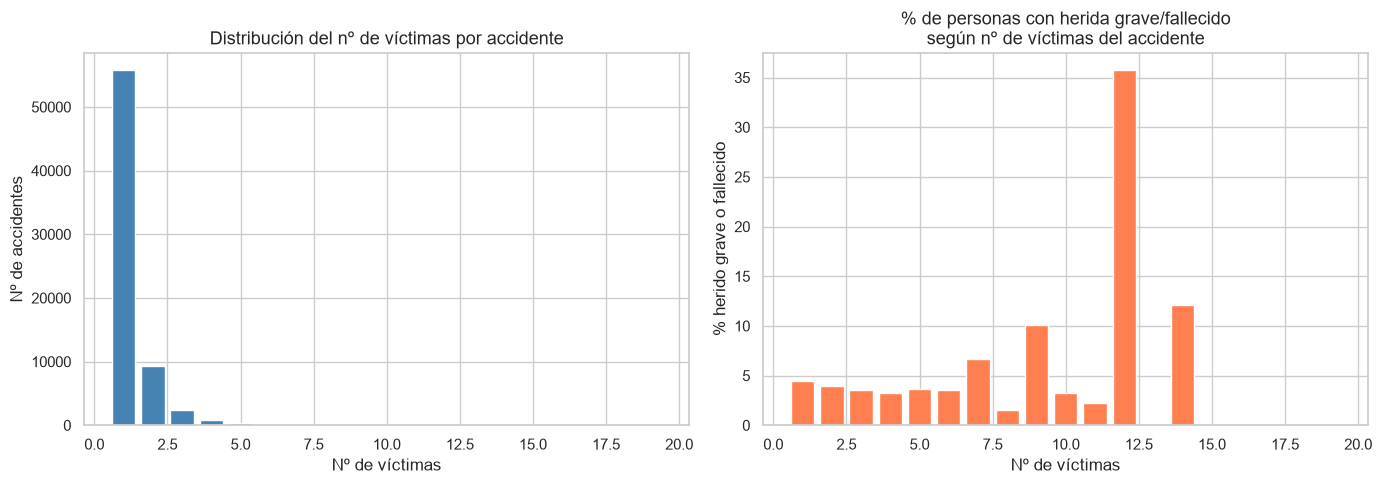

In [127]:
# Número de víctimas por accidente
victimas_dist = df.drop_duplicates('Nº PARTE')['Nº VICTIMAS *'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(victimas_dist.index, victimas_dist.values, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución del nº de víctimas por accidente', fontsize=13)
axes[0].set_xlabel('Nº de víctimas')
axes[0].set_ylabel('Nº de accidentes')

# Tasa de gravedad según nº de víctimas
df_vic = df_sin_na.copy()
tasa_grave_vic = df_vic.groupby('Nº VICTIMAS *')['GRAVE'].mean() * 100

axes[1].bar(tasa_grave_vic.index, tasa_grave_vic.values, color='coral', edgecolor='white')
axes[1].set_title('% de personas con herida grave/fallecido\nsegún nº de víctimas del accidente', fontsize=13)
axes[1].set_xlabel('Nº de víctimas')
axes[1].set_ylabel('% herido grave o fallecido')

plt.tight_layout()
plt.savefig('../figures/15_victimas_por_accidente.png', dpi=150)
plt.show()

### 📝 Resumen — Sección 6

> - El tipo de persona más frecuente en los accidentes es...
> - Los peatones presentan una mayor proporción de heridos graves que conductores y viajeros.
> - Los tramos de edad con más lesividad grave son los mayores de 65 y...
> - Los hombres representan un mayor volumen de accidentes. En términos de gravedad relativa...
> - Los vehículos con mayor tasa de lesividad grave son las motocicletas y...
> - Los accidentes nocturnos (0h-6h) presentan una tasa de gravedad superior a la media.
> - La mayoría de accidentes tienen 1-2 víctimas. A mayor número de víctimas, mayor % de graves.

---
## 7. Conclusiones del EDA

En esta sección se recogen los hallazgos más relevantes del análisis exploratorio y se extraen las implicaciones para la fase de preprocesado y modelización.

### Variables más prometedoras para el modelo

| Variable | Tipo | Observación |
|----------|------|-------------|
| `TIPO ACCIDENTE` | Categórica | Alta variabilidad en gravedad según tipo |
| `RANGO HORARIO` | Categórica | Accidentes nocturnos con mayor tasa de gravedad |
| `DIA SEMANA` | Categórica | Diferencias entre días laborables y fin de semana |
| `DISTRITO` | Categórica | Heterogeneidad geográfica en tasa de gravedad |
| `CPFA_*` | Binaria | Condiciones adversas relacionadas con gravedad |
| `CPSV_*` | Binaria | Estado del firme relacionado con la gravedad |
| `Tramo Edad` | Categórica | Mayores y muy jóvenes más vulnerables |
| `TIPO PERSONA` | Categórica | Los peatones presentan mayor lesividad |
| `Tipo Vehiculo` | Categórica | Motocicletas con mayor tasa de HG+MT |
| `Nº VICTIMAS *` | Numérica | A mayor nº víctimas, mayor probabilidad de gravedad |

### Decisiones tomadas para la fase de preprocesado

> 1. La variable objetivo se construirá como la LESIVIDAD máxima por accidente (`Nº PARTE`)
> 2. Se excluyen testigos (ya aplicado en este notebook)
> 3. Se eliminan 4.065 filas duplicadas exactas (errores de registro)
> 4. Se eliminan los 7.860 registros con LESIVIDAD 'NO ASIGNADA'
> 5. Se usará **clasificación binaria**: Leve/Sin heridos vs. Grave/Fallecido
> 6. El dataset presenta desequilibrio de clases (~4% graves): se abordará con `class_weight` o SMOTE en modelización

In [128]:
# Resumen final
print('=== RESUMEN DEL EDA ===')
print(f'Total registros (sin testigos): {len(df):,}')
print(f'Total accidentes únicos: {df["Nº PARTE"].nunique():,}')
print(f'Período: {df["FECHA"].min().date()} — {df["FECHA"].max().date()}')
print(f'\nDistribución de LESIVIDAD:')
print(df['LESIVIDAD'].value_counts(normalize=True).mul(100).round(2).to_string())
print(f'\nDesequilibrio de clases (Grave+MT vs resto): '
      f'{df["LESIVIDAD"].isin(["HG","MT"]).mean()*100:.2f}% graves')

=== RESUMEN DEL EDA ===
Total registros (sin testigos): 174,353
Total accidentes únicos: 68,773
Período: 2012-01-01 — 2018-12-31

Distribución de LESIVIDAD:
LESIVIDAD
HL             46.38
IL             45.04
NO ASIGNADA     4.51
HG              3.95
MT              0.12

Desequilibrio de clases (Grave+MT vs resto): 4.07% graves
